<a href="https://colab.research.google.com/github/anwaruddin1/Bioinformatics-Workshop/blob/main/01_scRNAseq_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
untar("R_library.tar.gz")
#list.files("library")

In [2]:
# change the R library directory into './library'
.libPaths("library")

In [3]:
library('Seurat')
library('dplyr')
library('patchwork')
library('SoupX')
library("matrixStats")
library("ggplot2")
library("SingleCellExperiment")
library("scran")
library(tidyr)
library("tibble")
library(cluster)
library(tidyverse)
library(viridis)
library(ggforce)
library(gghalves)
library(ggridges)
library(reshape2)
library(ape)
library(ggtree)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count


Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, col

In [ ]:
#devtools::install_version("Matrix",version = "1.6.1.1")

In [ ]:
#install.packages('remotes')

In [ ]:
#install.packages('devtools')

In [ ]:
#install.packages('SeuratObject')

In [4]:
untar("cellranger_output.tar")

# Read pre-treatment data

In [5]:
# Load data and estimate soup profile

filtd.matrix <- Read10X(data.dir = "cellranger_output/pre-treatment/filtered_feature_bc_matrix")
raw.matrix <- Read10X(data.dir = "cellranger_output/pre-treatment/raw_feature_bc_matrix")

In [6]:
# Make a Seurat object from the sparce matrix as follows:
srat  <- CreateSeuratObject(counts = filtd.matrix)
srat

An object of class Seurat 
38606 features across 660 samples within 1 assay 
Active assay: RNA (38606 features, 0 variable features)
 1 layer present: counts

In [7]:
filt_genes <- rownames(filtd.matrix)

In [8]:
# Subset raw.matrix to keep only the genes in filt.matrix
# Since the provided table of droplets (tod) and table of counts (toc) have different numbers of genes.  Both tod and toc must have the same genes in the same order.
raw.matrix.subset <- raw.matrix[rownames(raw.matrix) %in% filt_genes, ]

In [9]:
# Let’s make a “SoupChannel”, the object needed to run SoupX.
preT_data_SoupX = SoupChannel(raw.matrix.subset, filtd.matrix, calcSoupProfile = FALSE)
preT_data_SoupX

Channel with 38606 genes and 660 cells



In [10]:
srat <- SCTransform(srat, verbose = F)
srat <- RunPCA(srat, verbose = F)
srat <- RunUMAP(srat, dims = 1:30, verbose = F)
srat <- FindNeighbors(srat, dims = 1:30, verbose = F)
srat <- FindClusters(srat, verbose = T)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 660
Number of edges: 20026

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7765
Number of communities: 8
Elapsed time: 0 seconds


In [11]:
DefaultAssay(srat) <- "SCT"

In [12]:
# After clustering is obtained, it can be added to the channel using setClusters. setDR is useful for visualizations.
meta    <- srat@meta.data
umap    <- srat@reductions$umap@cell.embeddings
preT_data_SoupX  <- setClusters(preT_data_SoupX, setNames(meta$seurat_clusters, rownames(meta)))
preT_data_SoupX  <- setDR(preT_data_SoupX, umap)
#head(meta)

In [13]:
preT_data_SoupX = estimateSoup(preT_data_SoupX)

In [14]:
# Genes with highest expression in background. These are often enriched for ribosomal proteins.
head(preT_data_SoupX$soupProfile[order(preT_data_SoupX$soupProfile$est, decreasing = T), ], n = 20)

,est,counts
,<dbl>,<dbl>
FTL,0.019938390,8110
MT-CO1,0.017263548,7022
MT-CO2,0.017226671,7007
MALAT1,0.015596689,6344
MT-ATP6,0.015385258,6258
MT-CO3,0.015036152,6116
FTH1,0.012776796,5197
GAPDH,0.010824751,4403
MT-ND4,0.009465204,3850


In [15]:
macroGenes = c('NRG1', 'CSMD1')

## Estimating non-expressing cells

Having decided on a set of genes with which to estimate the contamination, we next need to decide which cells genuinely express these genes and should not be used for estimating the contamination, and which do not and should. This is done as follows:

In [16]:
useToEst_preT = estimateNonExpressingCells(preT_data_SoupX, nonExpressedGeneList = list(IG = macroGenes))

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the SoupX package.
  Please report the issue to the authors.”


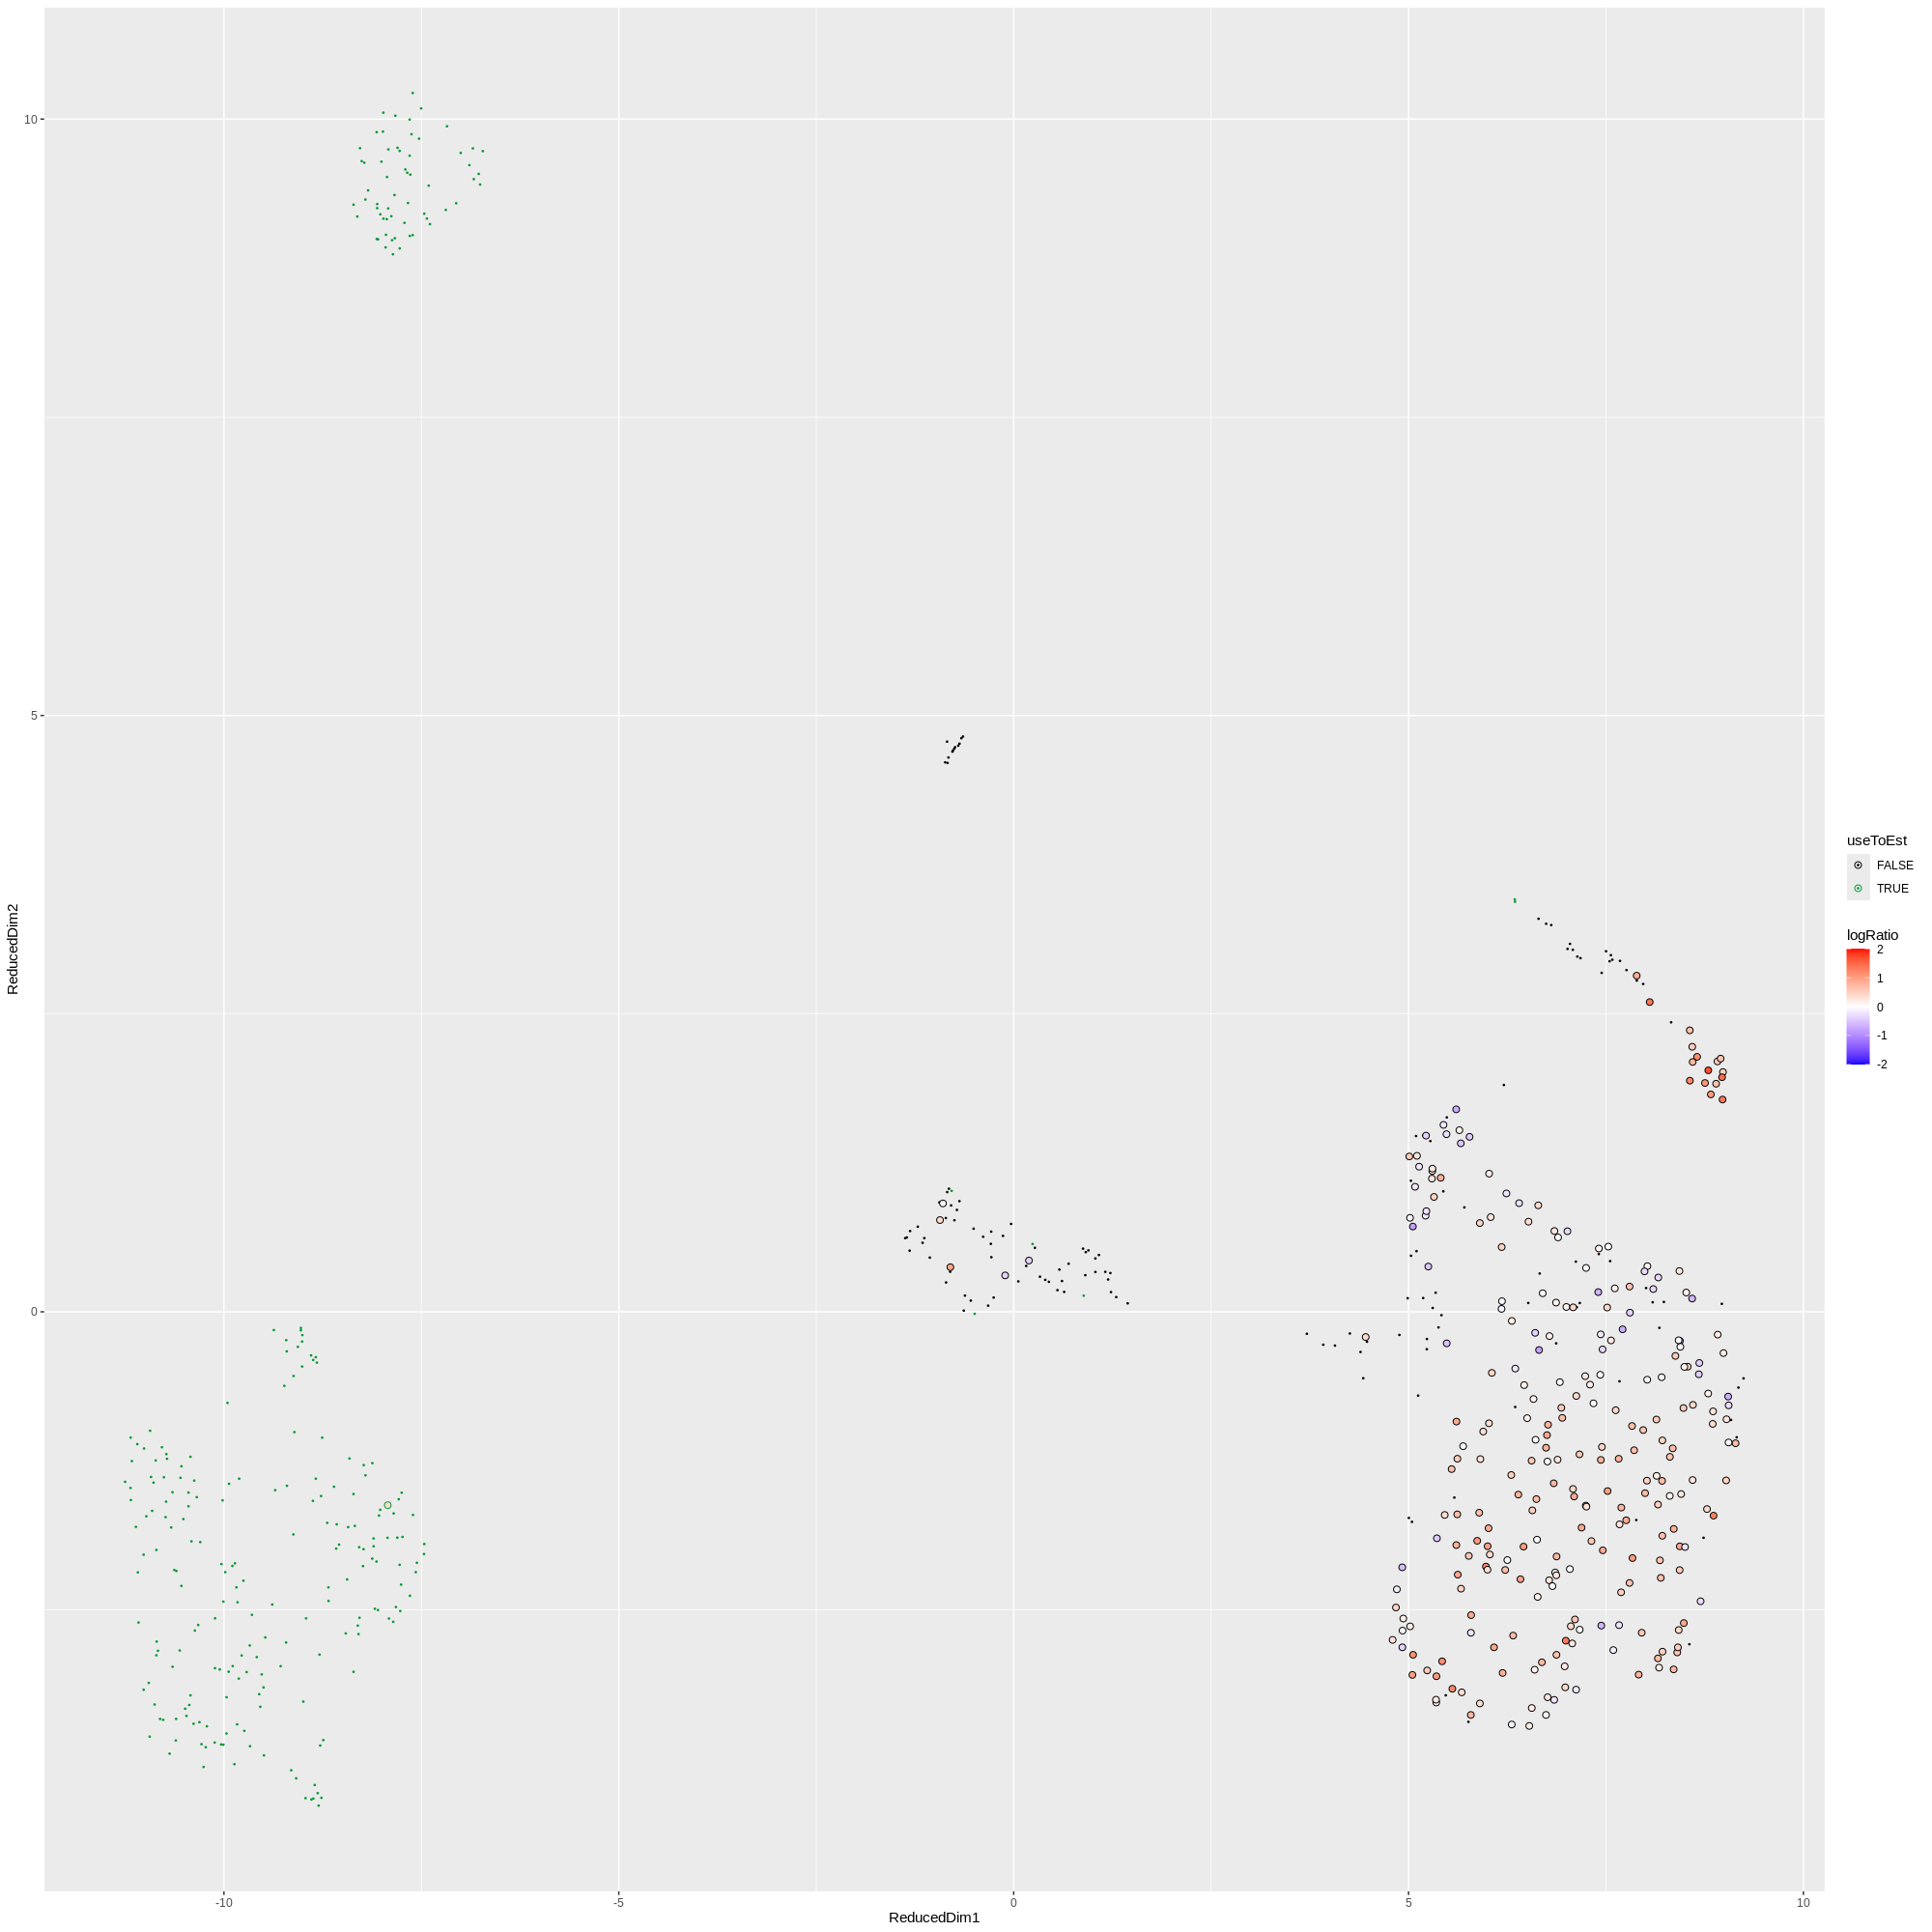

In [17]:
options(repr.plot.width = 20, repr.plot.height = 20, repr.plot.res = 100)
plotMarkerMap(preT_data_SoupX, geneSet = macroGenes, useToEst = useToEst_preT, pointSize = 2)

## Calculating the contamination fraction
To estimate the contamination fraction you need only pass your set of genes and which cells in which to use those sets of genes to calculateContaminationFraction.

In [18]:
preT_data_SoupX = calculateContaminationFraction(preT_data_SoupX, nonExpressedGeneList = list(IG = macroGenes), useToEst = useToEst_preT, forceAccept=TRUE)

Estimated global contamination fraction of 0.86%



In [19]:
head(preT_data_SoupX$metaData)

,nUMIs,clusters,umap_1,umap_2,rho,rhoLow,rhoHigh
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAACCCAAGTACAACA-1,21674,0,8.214091,-1.078138,0.008630623,0.0004922137,0.03796377
AAACCCACATCCGGCA-1,2204,4,-7.981516,10.054041,0.008630623,0.0004922137,0.03796377
AAACGAACAGGTGTGA-1,914,1,-9.841837,-2.310299,0.008630623,0.0004922137,0.03796377
AAACGAAGTTCGTTCC-1,1224,1,-10.602589,-2.172966,0.008630623,0.0004922137,0.03796377
AAAGAACTCCCATGGG-1,12064,0,6.351384,-0.475912,0.008630623,0.0004922137,0.03796377
AAAGAACTCGGTGTAT-1,1421,2,-7.605902,-1.703115,0.008630623,0.0004922137,0.03796377


## Correcting expression profile
We have now calculated or set the contamination fraction for each cell and would like to use this to remove the contamination from the original count matrix. As with estimating the contamination, this procedure is made much more robust by providing clustering information. This is because there is much more power to separate true expression from contaminating expression when counts are aggregated into clusters. Furthermore, the process of redistributing corrected counts from the cluster level to individual cells automatically corrects for variation in the cell specific contamination rate.
We have already loaded clustering information into our sc object with setClusters, which will be used by default. So we can just run.

In [20]:
preT_data_SoupX_out = adjustCounts(preT_data_SoupX)

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 8 clusters to 660 cells.



## Investigating changes in expression
Before proceeding let’s have a look at what this has done. We can get a sense for what has been the most strongly decreased by looking at the fraction of cells that were non-zero and now set to zero after correction.

In [21]:
cntSoggy = rowSums(preT_data_SoupX$toc > 0)
cntStrained = rowSums(preT_data_SoupX_out > 0)
mostZeroed = tail(sort((cntSoggy - cntStrained)/cntSoggy), n = 10)
mostZeroed

IGHG3     IGLC3      IGHD      APOE     IGLC2     IGHA1      IGKC  IGLV1-47 
0.1250000 0.2142857 0.2222222 0.2340426 0.3200000 0.3555556 0.4431818 0.5000000 
      HBB       ZFY 
0.5714286 0.7500000

#### If on the other hand we focus on genes for which there is a quantitative difference, we find genes associated with metabolism and translation. This is often the case as mitochondrial genes are over represented in the background compared to cells, presumably as a result of the soup being generated from distressed cells.

In [22]:
tail(sort(rowSums(preT_data_SoupX$toc > preT_data_SoupX_out)/rowSums(preT_data_SoupX$toc > 0)), n = 20)

PCDH11Y ENSG00000291032          MT-ND1          MT-ND2          MT-CO1 
              1               1               1               1               1 
         MT-CO2         MT-ATP8         MT-ATP6          MT-CO3          MT-ND3 
              1               1               1               1               1 
        MT-ND4L          MT-ND4          MT-ND5          MT-ND6          MT-CYB 
              1               1               1               1               1 
ENSG00000278384 ENSG00000273748 ENSG00000271254 ENSG00000276345 ENSG00000278817 
              1               1               1               1               1

## Visualising expression distribution
Way back at the start, we did a quick visualisation to look at how the ratio of gene expression to pure soup was distributed. Now that we’ve corrected our data, we can see how that compares to our corrected data. The function plotChangeMap can help us with this. By default it plots the fraction of expression in each cell that has been deemed to be soup and removed.

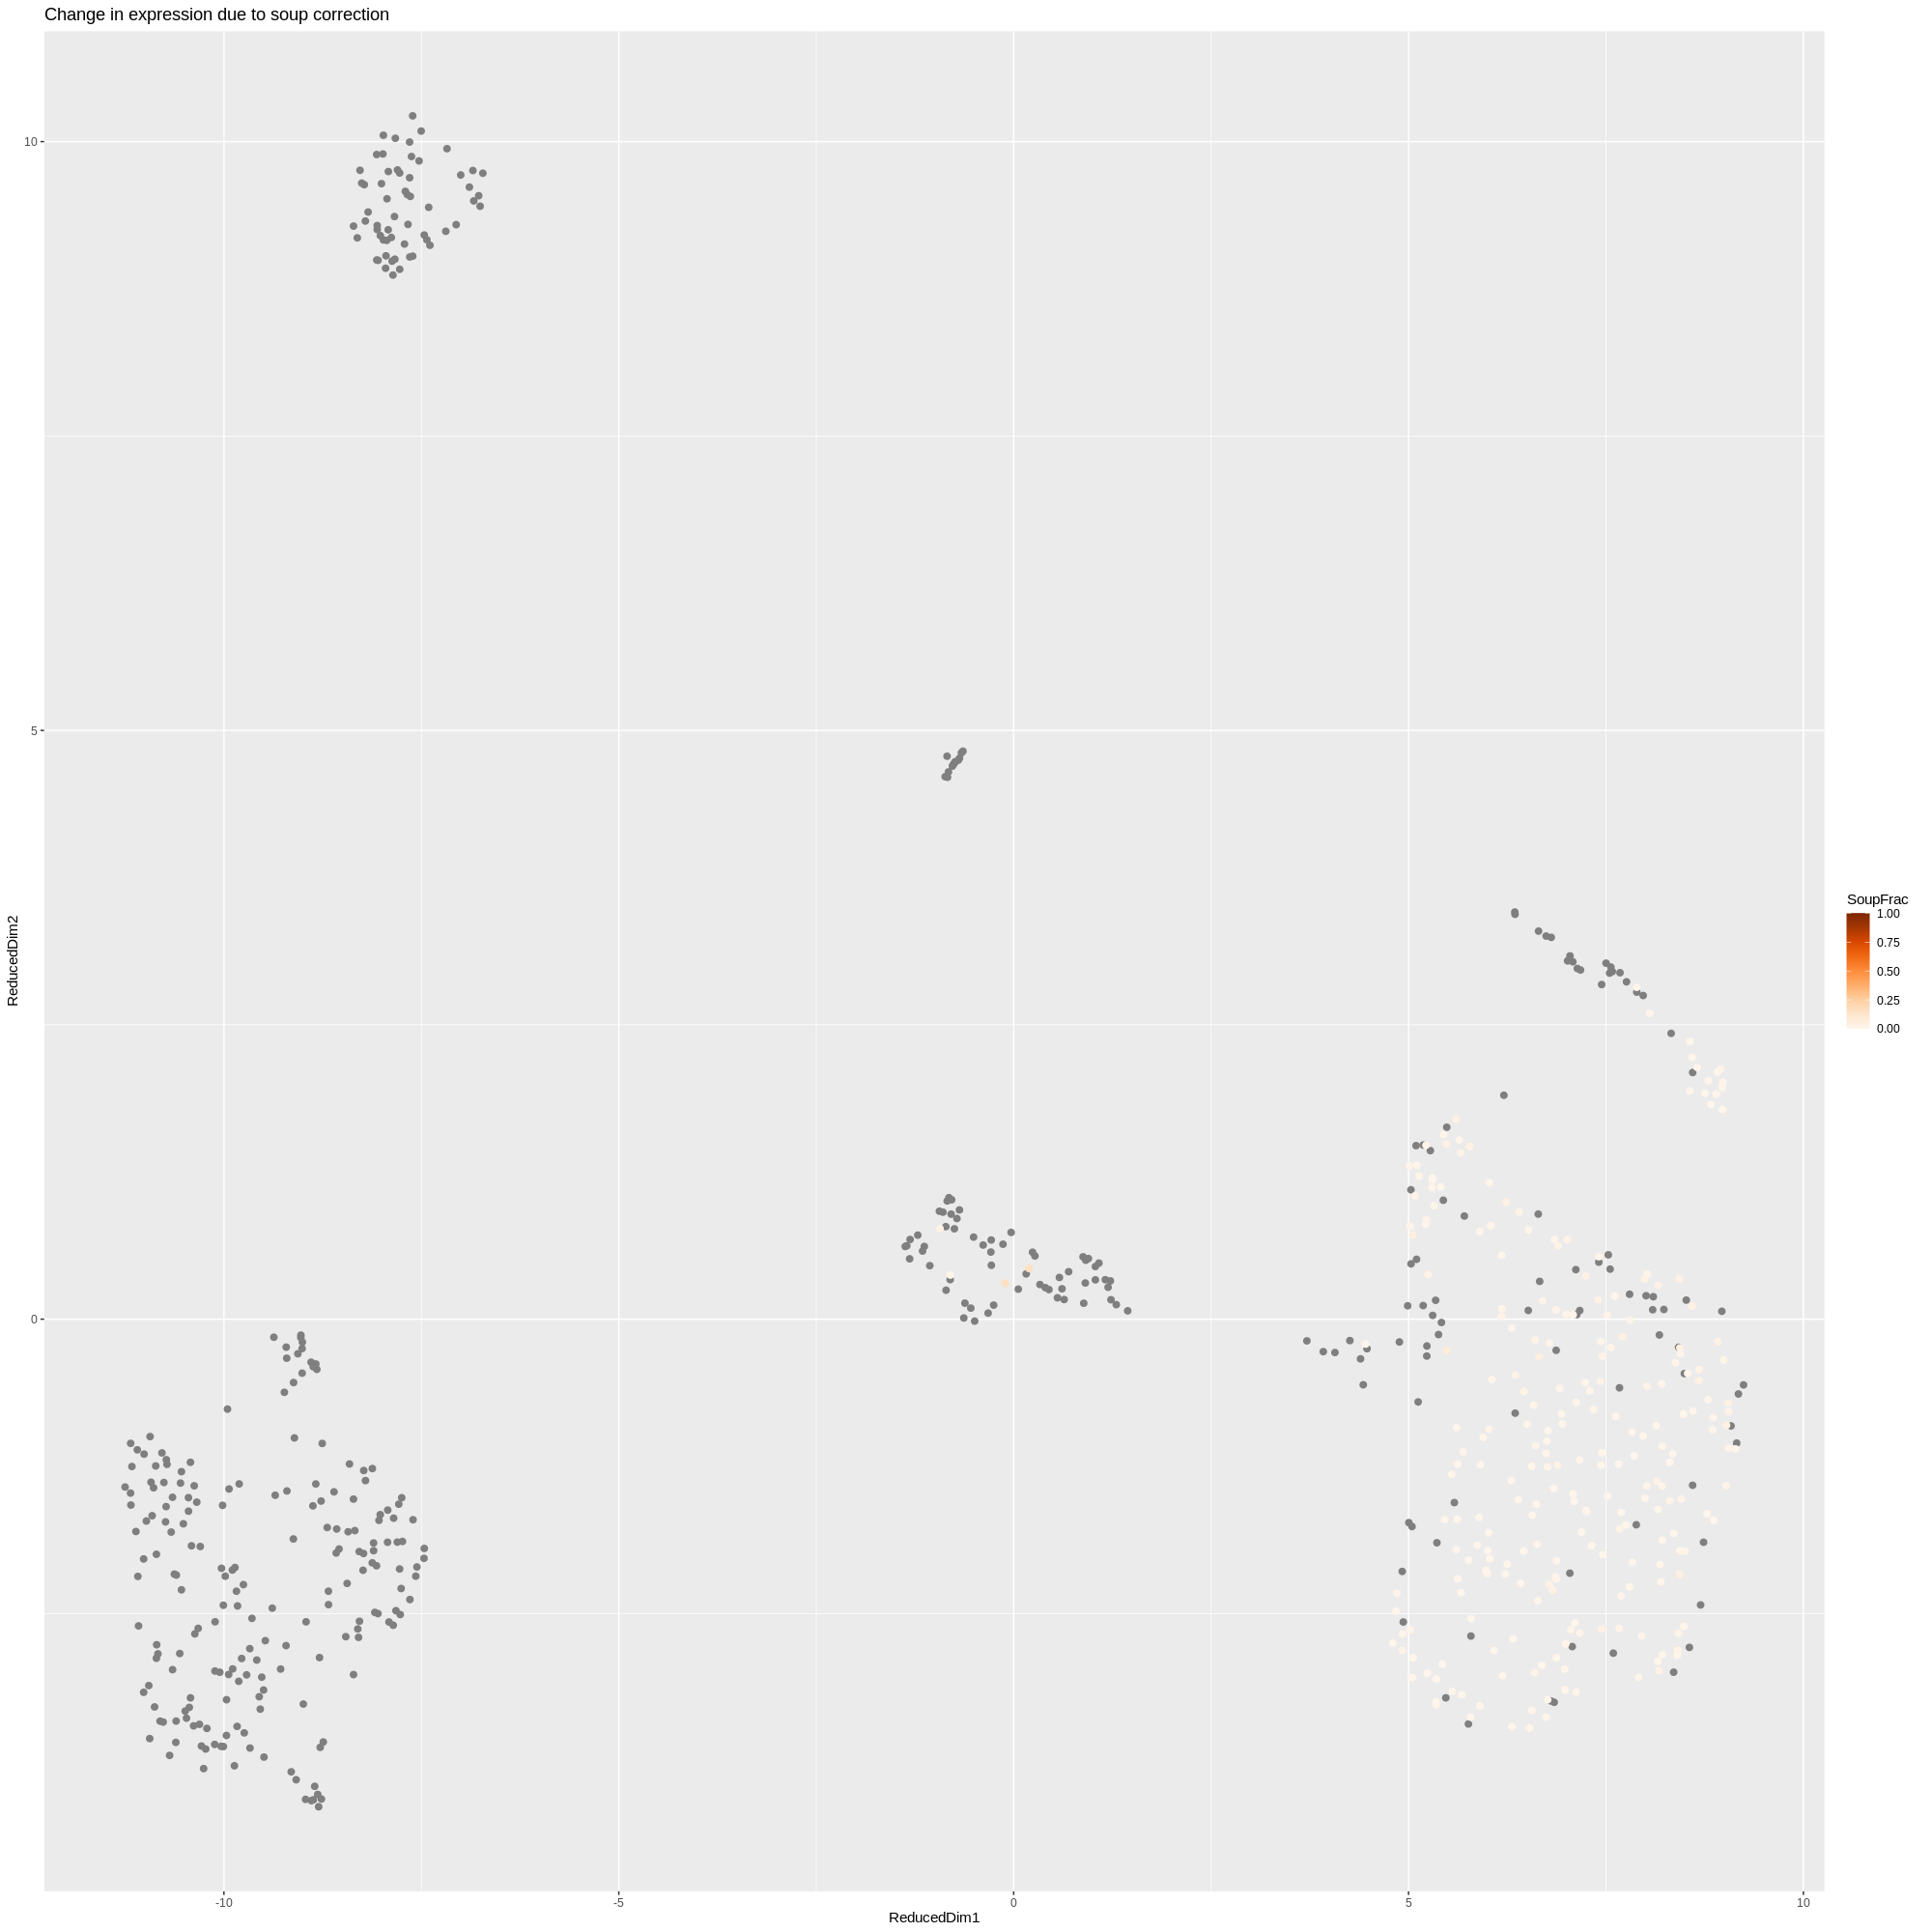

In [23]:
options(repr.plot.width = 20, repr.plot.height = 20, repr.plot.res = 100)
plotChangeMap(preT_data_SoupX, preT_data_SoupX_out, "NRG1", pointSize = 2)

In [24]:
# Initialize the Seurat object with the raw (non-normalized data).
preT <- CreateSeuratObject(counts = preT_data_SoupX_out, project = "preT", min.cells = 3, min.features = 500)
preT[["percent.mt"]] <- PercentageFeatureSet(preT, pattern = "^MT-")
preT[["percent.ribo"]] <- PercentageFeatureSet(preT, pattern = "^RB|^RP")
preT

An object of class Seurat 
19649 features across 634 samples within 1 assay 
Active assay: RNA (19649 features, 0 variable features)
 1 layer present: counts

## Visualize the QC metrics, and use these to filter cells. We generally filter cells that have >5% mitochondrial counts but in this case I am not filtering any cell based on mitochondria gene expression

### Visualize QC metrics as a violin plot

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


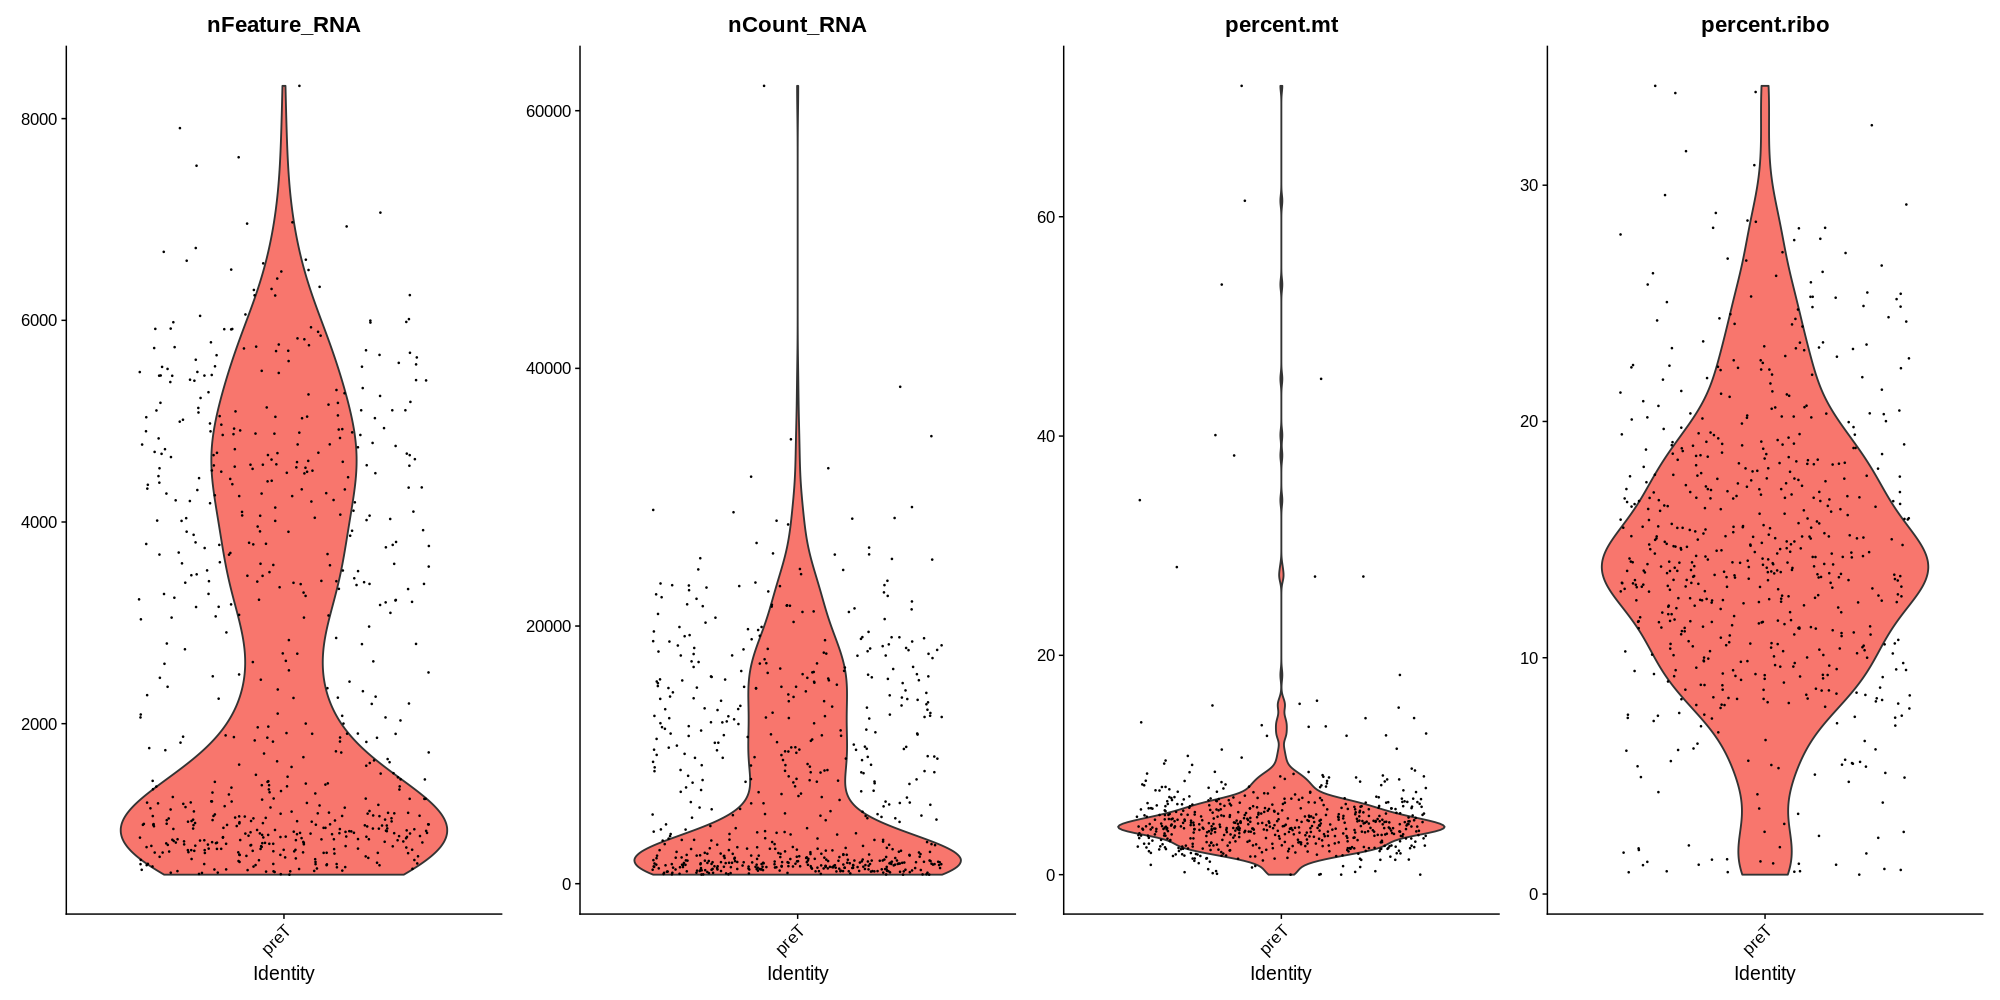

In [25]:
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 100)
VlnPlot(preT, features = c("nFeature_RNA", "nCount_RNA", "percent.mt", "percent.ribo"), ncol = 4)


### FeatureScatter is typically used to visualize feature-feature relationships, but can be used for anything calculated by the object, i.e. columns in object metadata, PC scores etc.

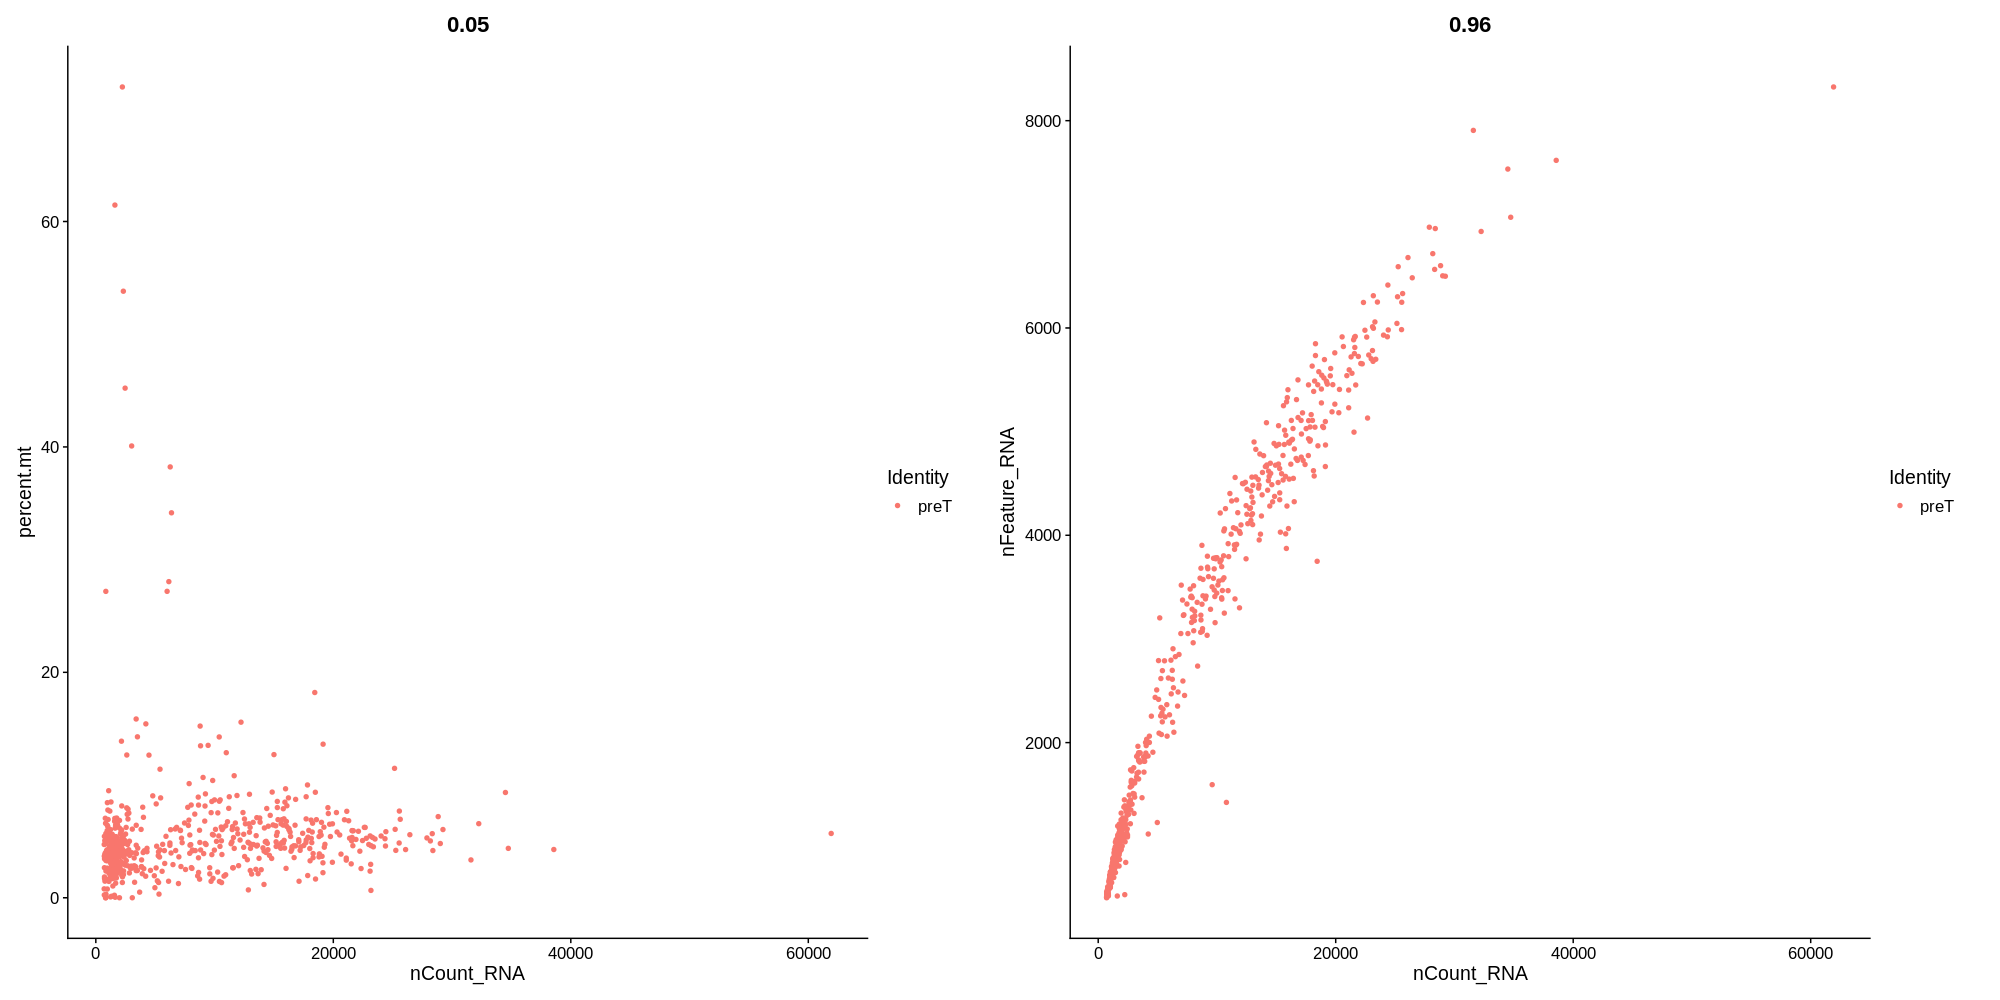

In [26]:
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 100)
plot1 <- FeatureScatter(preT, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(preT, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

### Outlier cells (Doublet) filtering filtering

In [27]:
preT <- subset(preT, subset = nFeature_RNA < 7000 & percent.mt < 10)
preT

An object of class Seurat 
19649 features across 597 samples within 1 assay 
Active assay: RNA (19649 features, 0 variable features)
 1 layer present: counts

### FeatureScatter is typically used to visualize feature-feature relationships, but can be used for anything calculated by the object, i.e. columns in object metadata, PC scores etc.

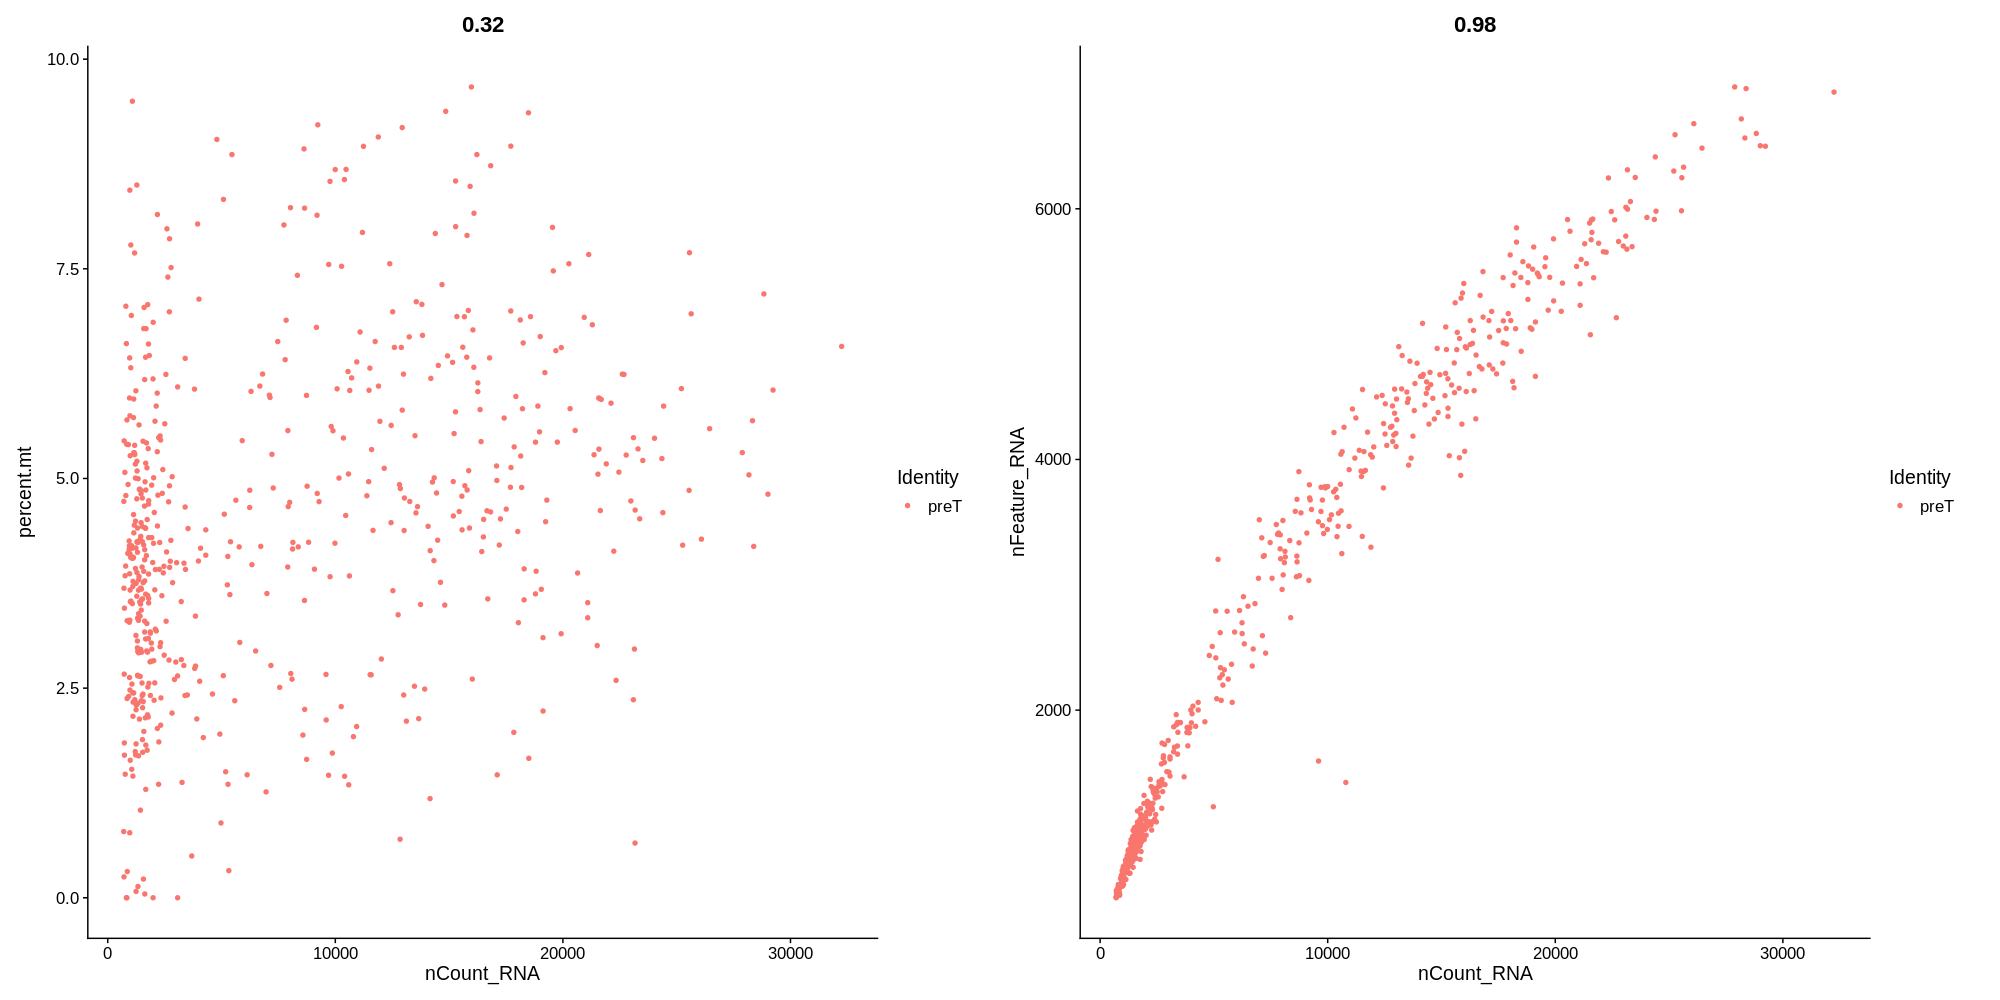

In [28]:
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 100)
plot1 <- FeatureScatter(preT, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(preT, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

In [29]:
# store mitochondrial percentage in object meta data
preT <- PercentageFeatureSet(preT, pattern = "^MT-", col.name = "percent.mt")
preT <- PercentageFeatureSet(preT, pattern = "^RB|^RP", col.name = "percent.ribo")


### Note that this single command replaces NormalizeData(), ScaleData(), and FindVariableFeatures().
### Transformed data will be available in the SCT assay, which is set as the default after running sctransform
### During normalization, we can also remove confounding sources of variation, for example, mitochondrial mapping percentage


In [30]:
# run sctransform
preT <- SCTransform(preT, vars.to.regress = "percent.mt", verbose = FALSE)

In [31]:
preT@meta.data$sample <- "preT"
preT

An object of class Seurat 
37102 features across 597 samples within 2 assays 
Active assay: SCT (17453 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA

# End of pre-treatment data processing

# **Loading Post-treatment data**

In [32]:
# Load data and estimate soup profile
filtd.matrix <- Read10X(data.dir = "cellranger_output/post-treatment/filtered_feature_bc_matrix")
raw.matrix <- Read10X(data.dir = "cellranger_output/post-treatment/raw_feature_bc_matrix")

In [33]:
# Make a Seurat object from the sparce matrix as follows:
srat  <- CreateSeuratObject(counts = filtd.matrix)
srat

An object of class Seurat 
38606 features across 1680 samples within 1 assay 
Active assay: RNA (38606 features, 0 variable features)
 1 layer present: counts

In [34]:
filt_genes <- rownames(filtd.matrix)

In [35]:
# Subset raw.matrix to keep only the genes in filt.matrix
# Since the provided table of droplets (tod) and table of counts (toc) have different numbers of genes.  Both tod and toc must have the same genes in the same order.
raw.matrix.subset <- raw.matrix[rownames(raw.matrix) %in% filt_genes, ]

In [36]:
# Let’s make a “SoupChannel”, the object needed to run SoupX.
postT_data_SoupX = SoupChannel(raw.matrix.subset, filtd.matrix, calcSoupProfile = FALSE)
postT_data_SoupX

Channel with 38606 genes and 1680 cells



In [37]:
srat <- SCTransform(srat, verbose = F)
srat <- RunPCA(srat, verbose = F)
srat <- RunUMAP(srat, dims = 1:30, verbose = F)
srat <- FindNeighbors(srat, dims = 1:30, verbose = F)
srat <- FindClusters(srat, verbose = T)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1680
Number of edges: 53706

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8573
Number of communities: 13
Elapsed time: 0 seconds


In [38]:
DefaultAssay(srat) <- "SCT"

In [39]:
# After clustering is obtained, it can be added to the channel using setClusters. setDR is useful for visualizations.
meta    <- srat@meta.data
umap    <- srat@reductions$umap@cell.embeddings
postT_data_SoupX  <- setClusters(postT_data_SoupX, setNames(meta$seurat_clusters, rownames(meta)))
postT_data_SoupX  <- setDR(postT_data_SoupX, umap)
#head(meta)

In [40]:
postT_data_SoupX = estimateSoup(postT_data_SoupX)

In [41]:
# Genes with highest expression in background. These are often enriched for ribosomal proteins.
head(postT_data_SoupX$soupProfile[order(postT_data_SoupX$soupProfile$est, decreasing = T), ], n = 20)

,est,counts
,<dbl>,<dbl>
MALAT1,0.033252286,38498
MT-ATP6,0.012806682,14827
MT-CO2,0.012375675,14328
IGKC,0.011325367,13112
MT-CO3,0.009686851,11215
MT-CO1,0.008743646,10123
MT-CYB,0.008201217,9495
FTL,0.008008603,9272
MT-ND3,0.007427305,8599


In [42]:
macroGenes = c('COL3A1', 'DCN')

## Estimating non-expressing cells

Having decided on a set of genes with which to estimate the contamination, we next need to decide which cells genuinely express these genes and should not be used for estimating the contamination, and which do not and should. This is done as follows:

In [43]:
useToEst_postT = estimateNonExpressingCells(postT_data_SoupX, nonExpressedGeneList = list(IG = macroGenes))

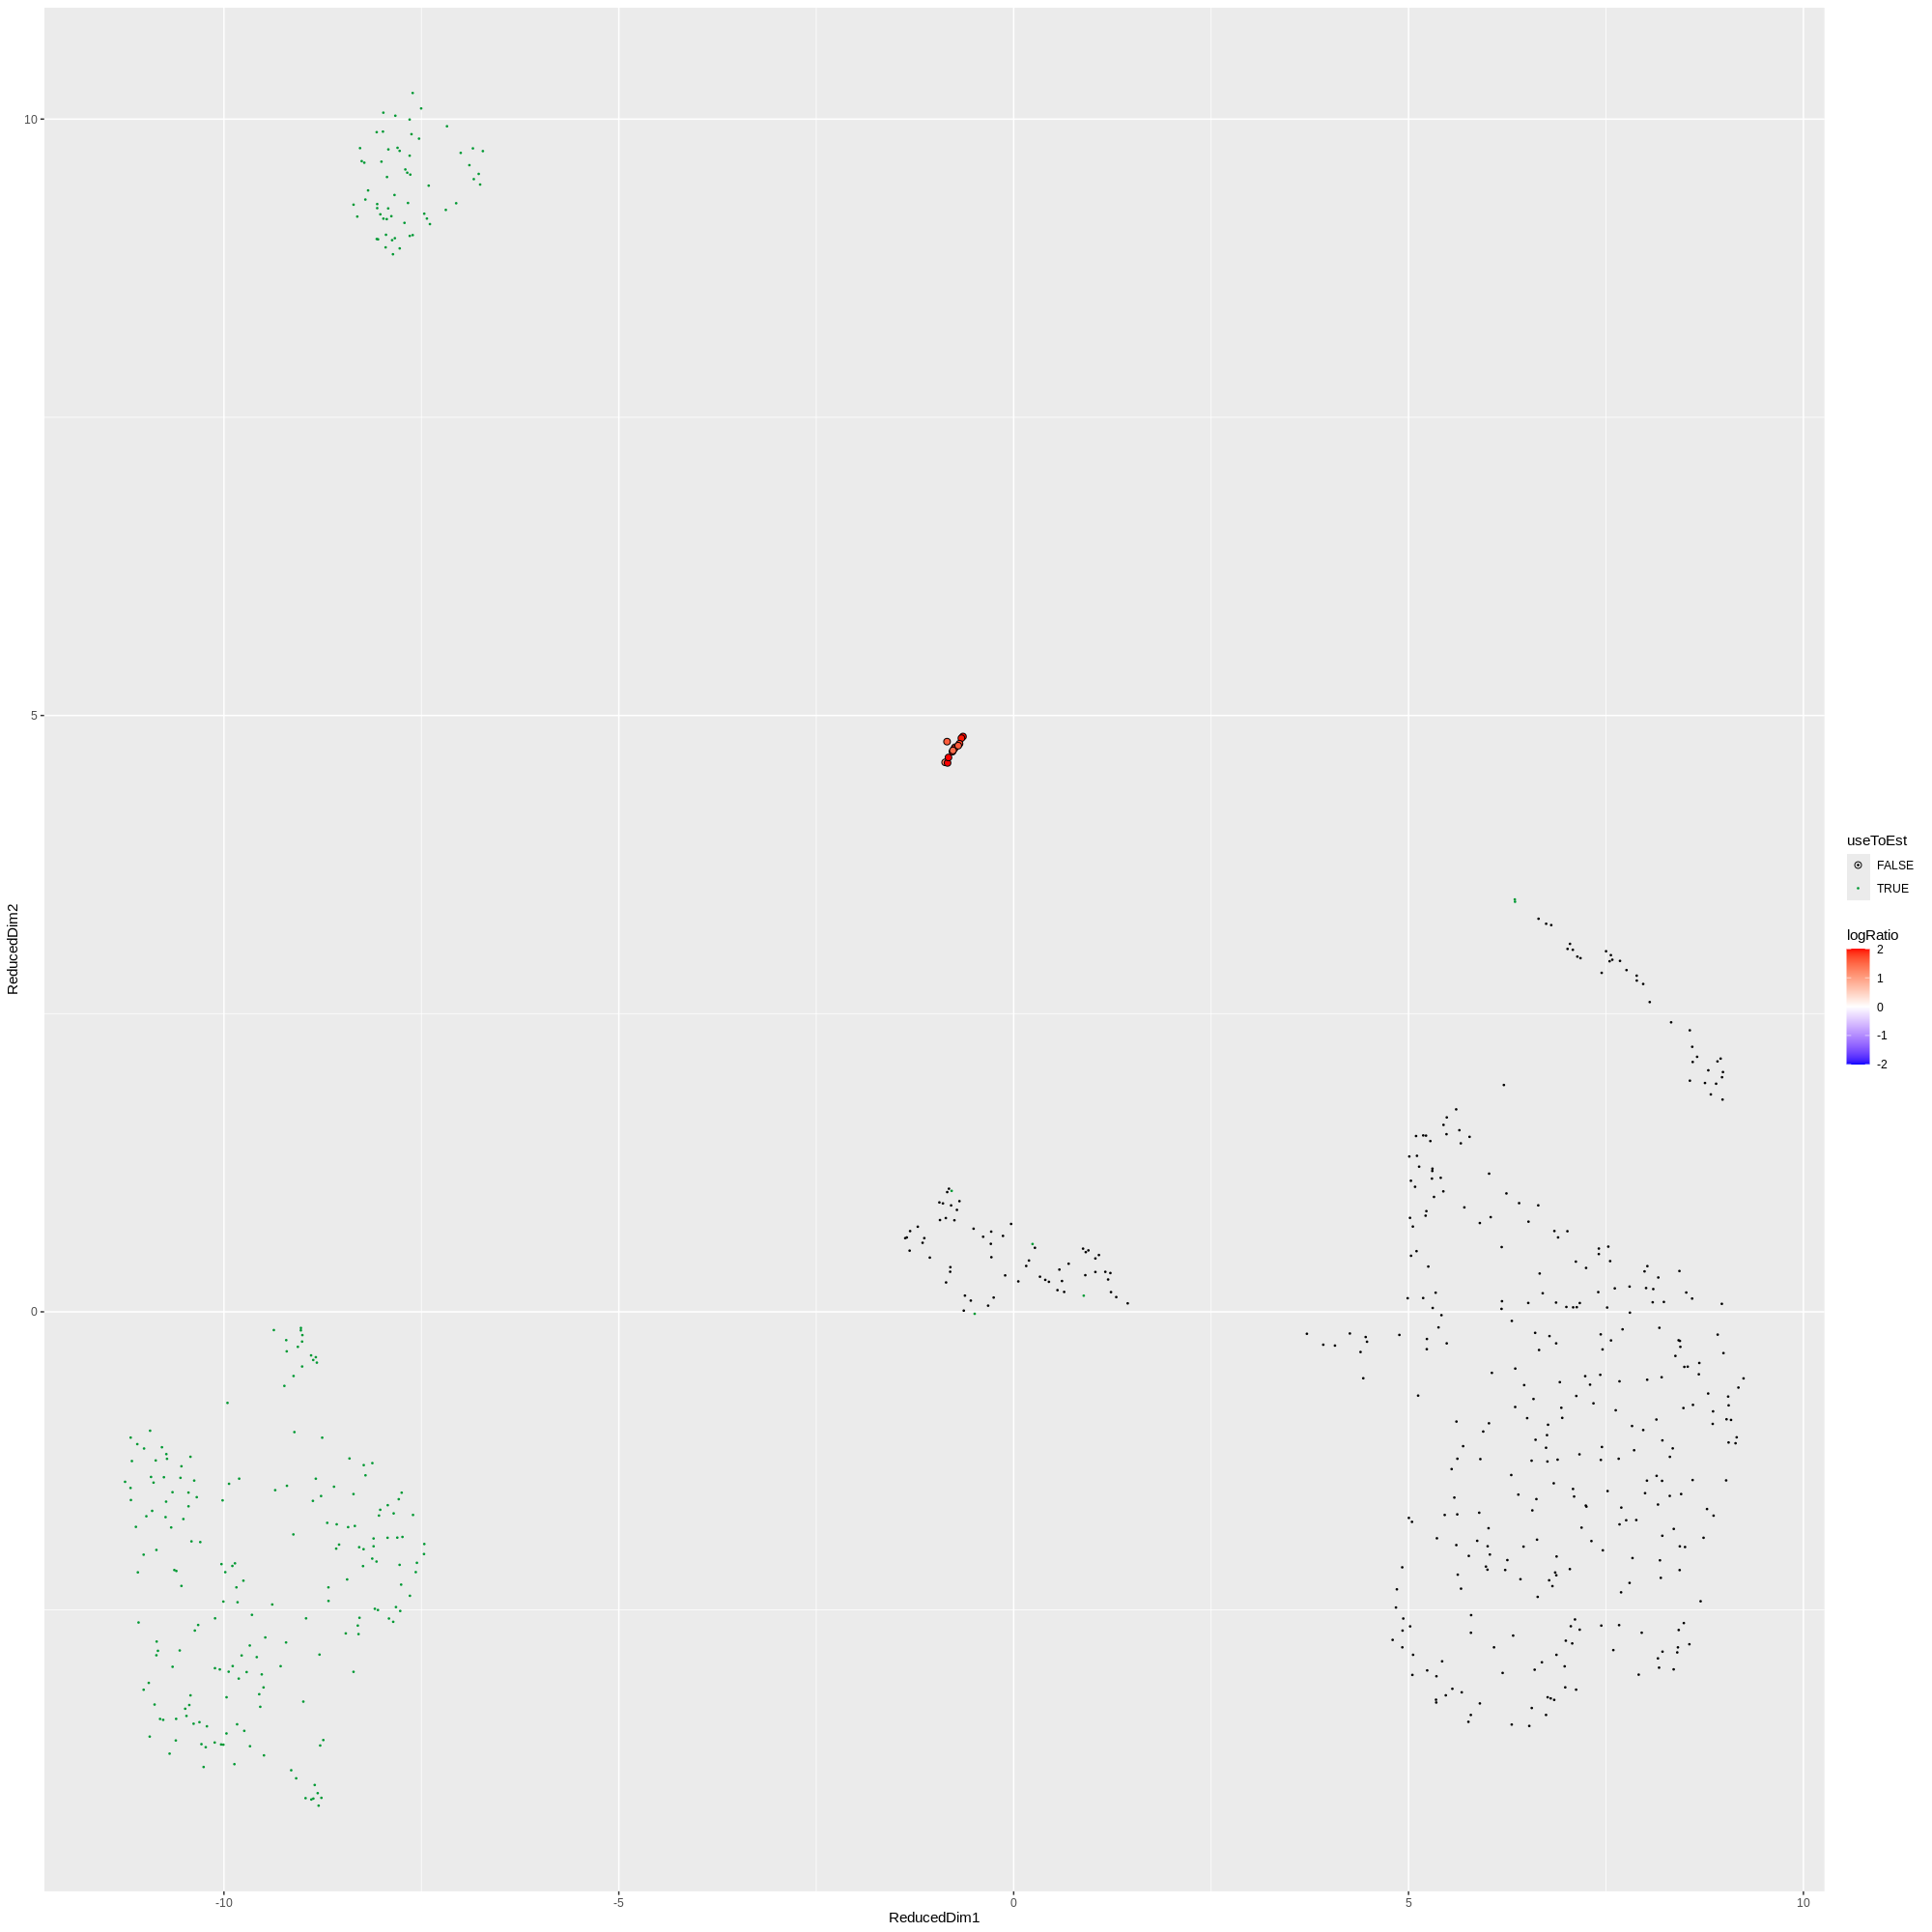

In [44]:
options(repr.plot.width = 20, repr.plot.height = 20, repr.plot.res = 100)
plotMarkerMap(preT_data_SoupX, geneSet = macroGenes, useToEst = useToEst_preT, pointSize = 2)

## Calculating the contamination fraction
To estimate the contamination fraction you need only pass your set of genes and which cells in which to use those sets of genes to calculateContaminationFraction.

In [45]:
postT_data_SoupX = calculateContaminationFraction(postT_data_SoupX, nonExpressedGeneList = list(IG = macroGenes), useToEst = useToEst_postT, forceAccept=TRUE)

Estimated global contamination fraction of 1.28%



In [46]:
head(postT_data_SoupX$metaData)

,nUMIs,clusters,umap_1,umap_2,rho,rhoLow,rhoHigh
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAACCCAAGTCGGGAT-1,958,2,-3.978701,-9.686183,0.01282342,0.009077563,0.01748019
AAACGAAAGCGTGAAC-1,2405,11,1.579502,-18.976049,0.01282342,0.009077563,0.01748019
AAACGAAAGGAACGCT-1,1561,2,-4.337970,-11.241425,0.01282342,0.009077563,0.01748019
AAACGAAGTATTAAGG-1,1691,0,7.827647,-6.847021,0.01282342,0.009077563,0.01748019
AAACGCTCACTCAGAT-1,1321,7,2.427808,11.379880,0.01282342,0.009077563,0.01748019
AAAGAACAGTTATGGA-1,2607,1,-4.974467,6.275405,0.01282342,0.009077563,0.01748019


## Correcting expression profile
We have now calculated or set the contamination fraction for each cell and would like to use this to remove the contamination from the original count matrix. As with estimating the contamination, this procedure is made much more robust by providing clustering information. This is because there is much more power to separate true expression from contaminating expression when counts are aggregated into clusters. Furthermore, the process of redistributing corrected counts from the cluster level to individual cells automatically corrects for variation in the cell specific contamination rate.
We have already loaded clustering information into our sc object with setClusters, which will be used by default. So we can just run.

In [47]:
postT_data_SoupX_out = adjustCounts(postT_data_SoupX)

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 13 clusters to 1680 cells.



## Investigating changes in expression
Before proceeding let’s have a look at what this has done. We can get a sense for what has been the most strongly decreased by looking at the fraction of cells that were non-zero and now set to zero after correction.

In [48]:
cntSoggy = rowSums(postT_data_SoupX$toc > 0)
cntStrained = rowSums(postT_data_SoupX_out > 0)
mostZeroed = tail(sort((cntSoggy - cntStrained)/cntSoggy), n = 10)
mostZeroed

IGHGP      IGHG1      SFTPC      IGLC2    SCGB3A1      IGHA1    SCGB1A1 
0.09433962 0.12500000 0.19230769 0.26315789 0.27142857 0.33333333 0.48000000 
       HBB      IGLC3       IGKC 
0.50000000 0.58536585 0.65454545

#### If on the other hand we focus on genes for which there is a quantitative difference, we find genes associated with metabolism and translation. This is often the case as mitochondrial genes are over represented in the background compared to cells, presumably as a result of the soup being generated from distressed cells.

In [49]:
tail(sort(rowSums(postT_data_SoupX$toc > postT_data_SoupX_out)/rowSums(postT_data_SoupX$toc > 0)), n = 20)

MT-ND1          MT-ND2          MT-CO1          MT-CO2         MT-ATP8 
              1               1               1               1               1 
        MT-ATP6          MT-CO3          MT-ND3         MT-ND4L          MT-ND4 
              1               1               1               1               1 
         MT-ND5          MT-ND6          MT-CYB           MAFIP ENSG00000276256 
              1               1               1               1               1 
ENSG00000278384 ENSG00000273748 ENSG00000271254 ENSG00000276345 ENSG00000277196 
              1               1               1               1               1

## Visualising expression distribution
Way back at the start, we did a quick visualisation to look at how the ratio of gene expression to pure soup was distributed. Now that we’ve corrected our data, we can see how that compares to our corrected data. The function plotChangeMap can help us with this. By default it plots the fraction of expression in each cell that has been deemed to be soup and removed.

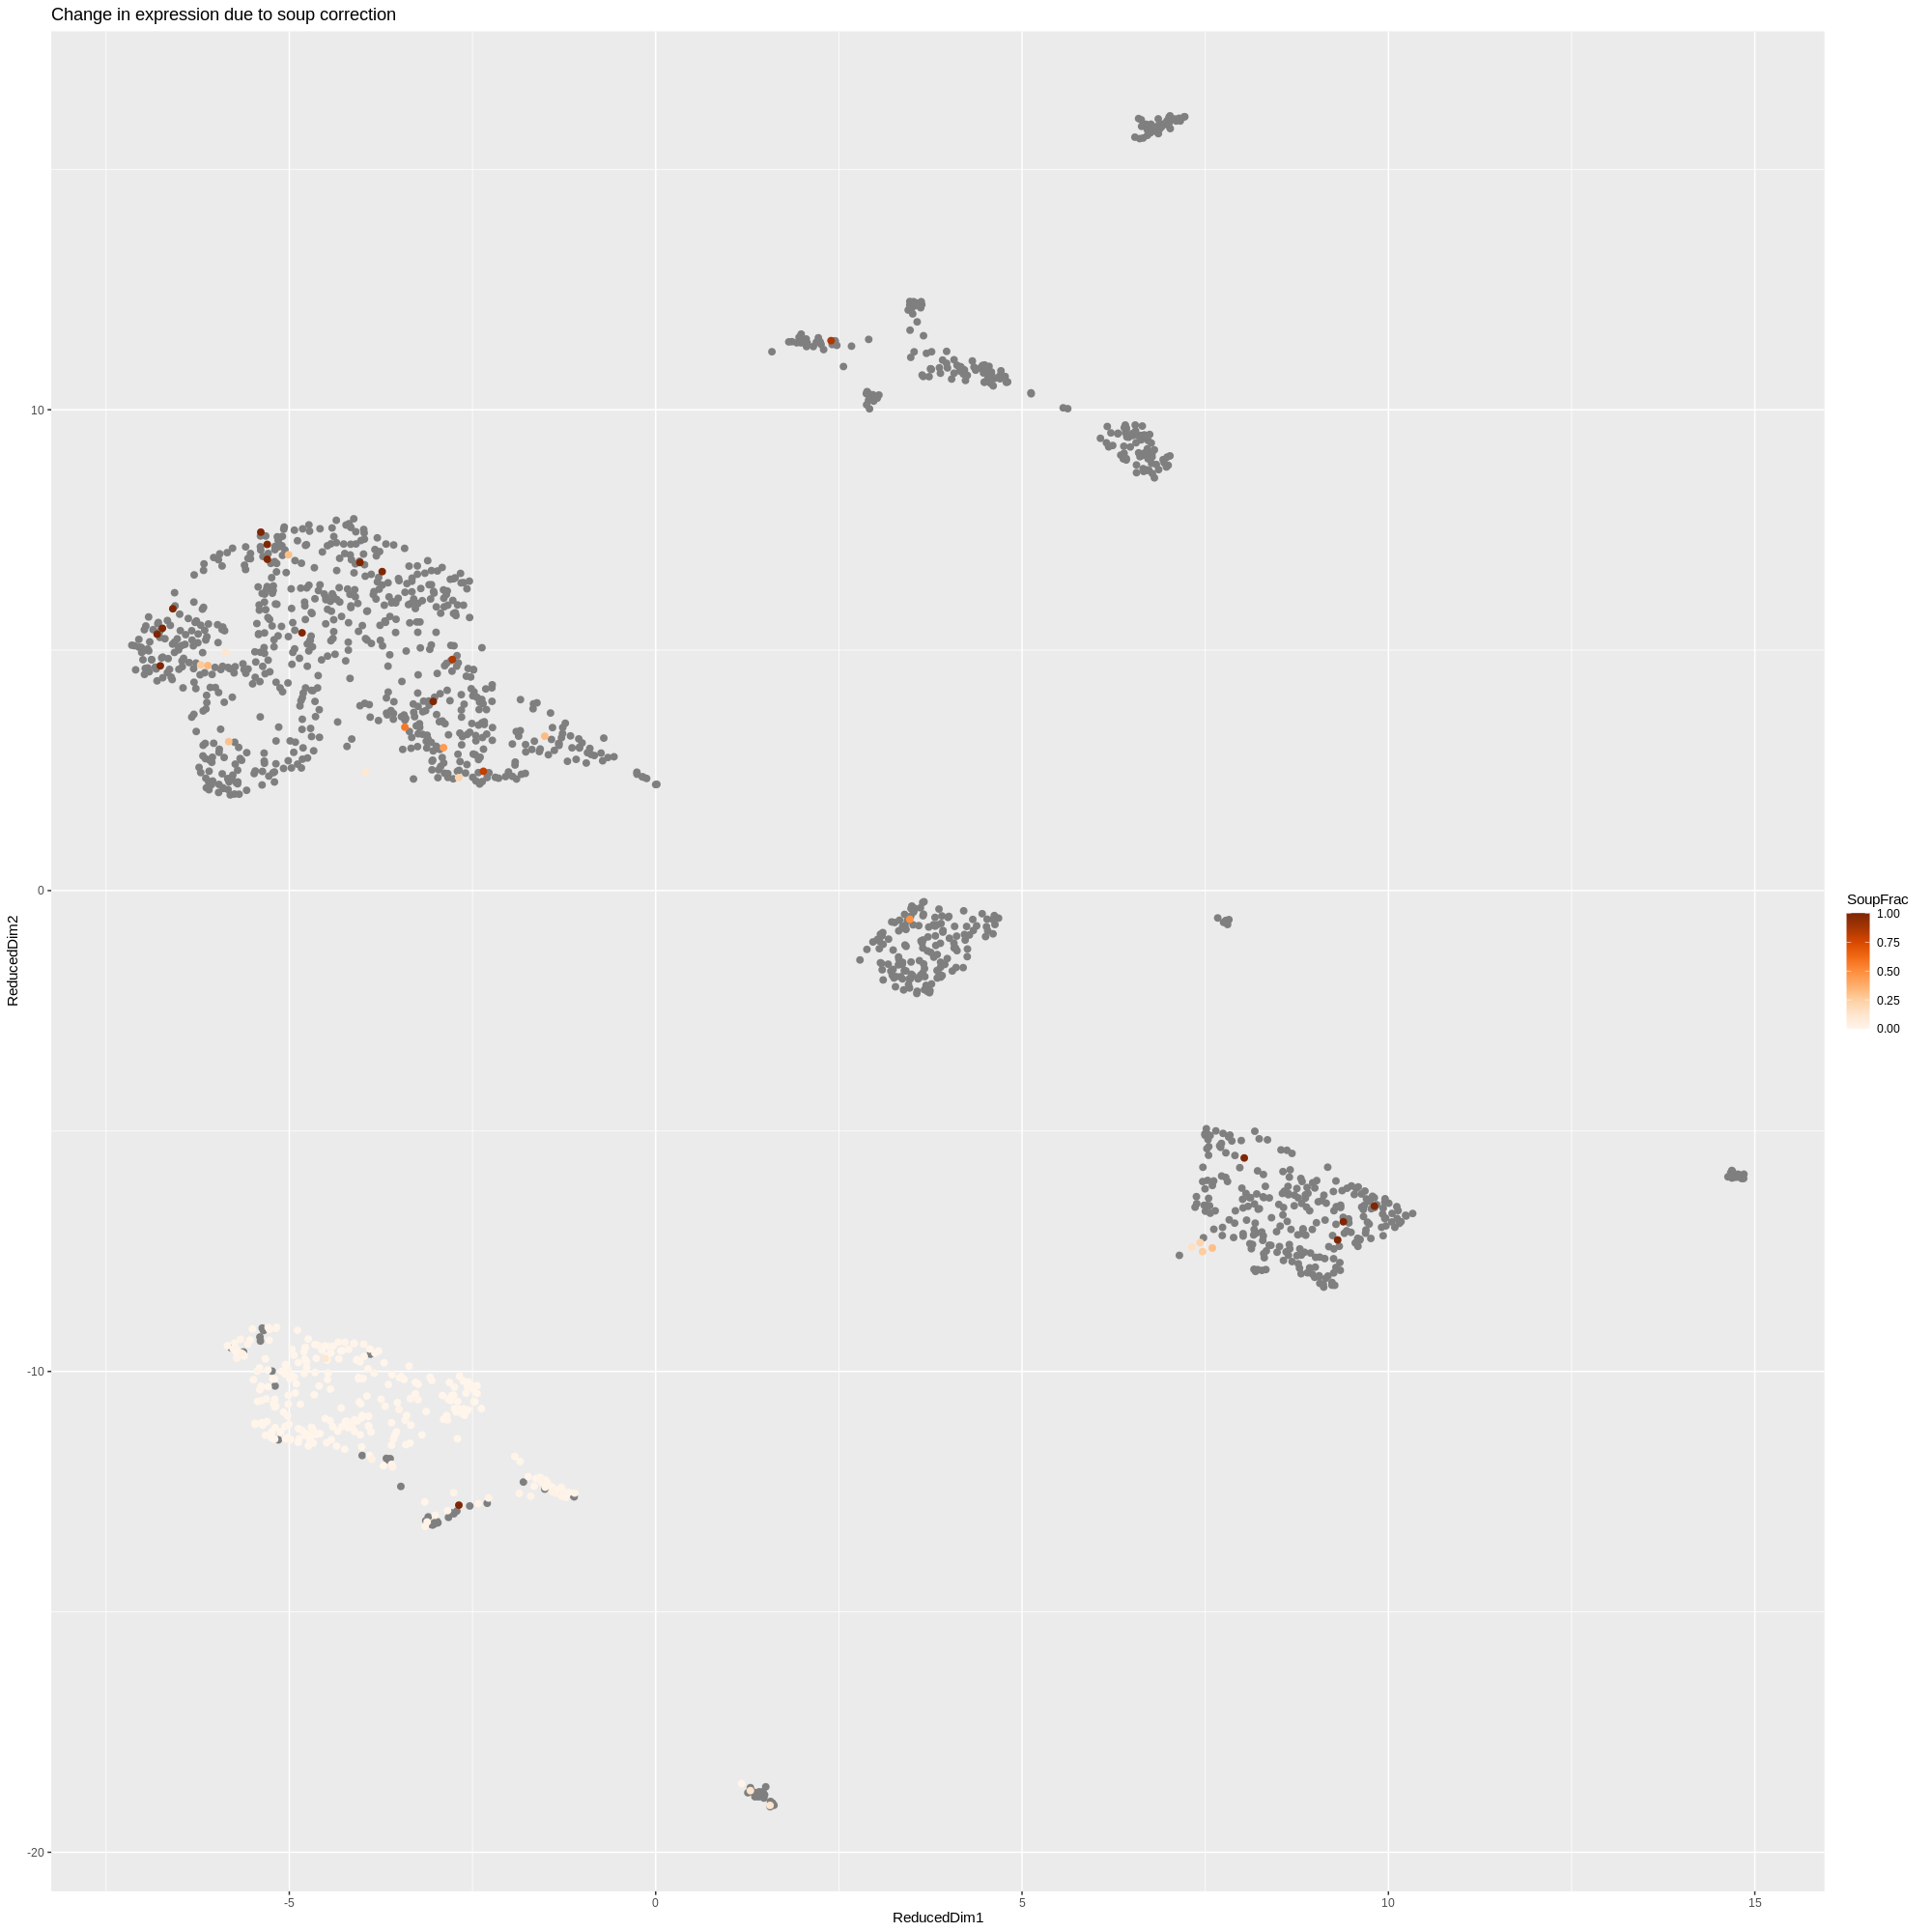

In [50]:
options(repr.plot.width = 20, repr.plot.height = 20, repr.plot.res = 100)
plotChangeMap(postT_data_SoupX, postT_data_SoupX_out, "COL3A1", pointSize = 2)

In [51]:
# Initialize the Seurat object with the raw (non-normalized data).
postT <- CreateSeuratObject(counts = postT_data_SoupX_out, project = "postT", min.cells = 3, min.features = 500)
postT[["percent.mt"]] <- PercentageFeatureSet(postT, pattern = "^MT-")
postT[["percent.ribo"]] <- PercentageFeatureSet(postT, pattern = "^RB|^RP")
postT

An object of class Seurat 
20217 features across 1395 samples within 1 assay 
Active assay: RNA (20217 features, 0 variable features)
 1 layer present: counts

## Visualize the QC metrics, and use these to filter cells. We generally filter cells that have >5% mitochondrial counts but in this case I am not filtering any cell based on mitochondria gene expression

### Visualize QC metrics as a violin plot

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


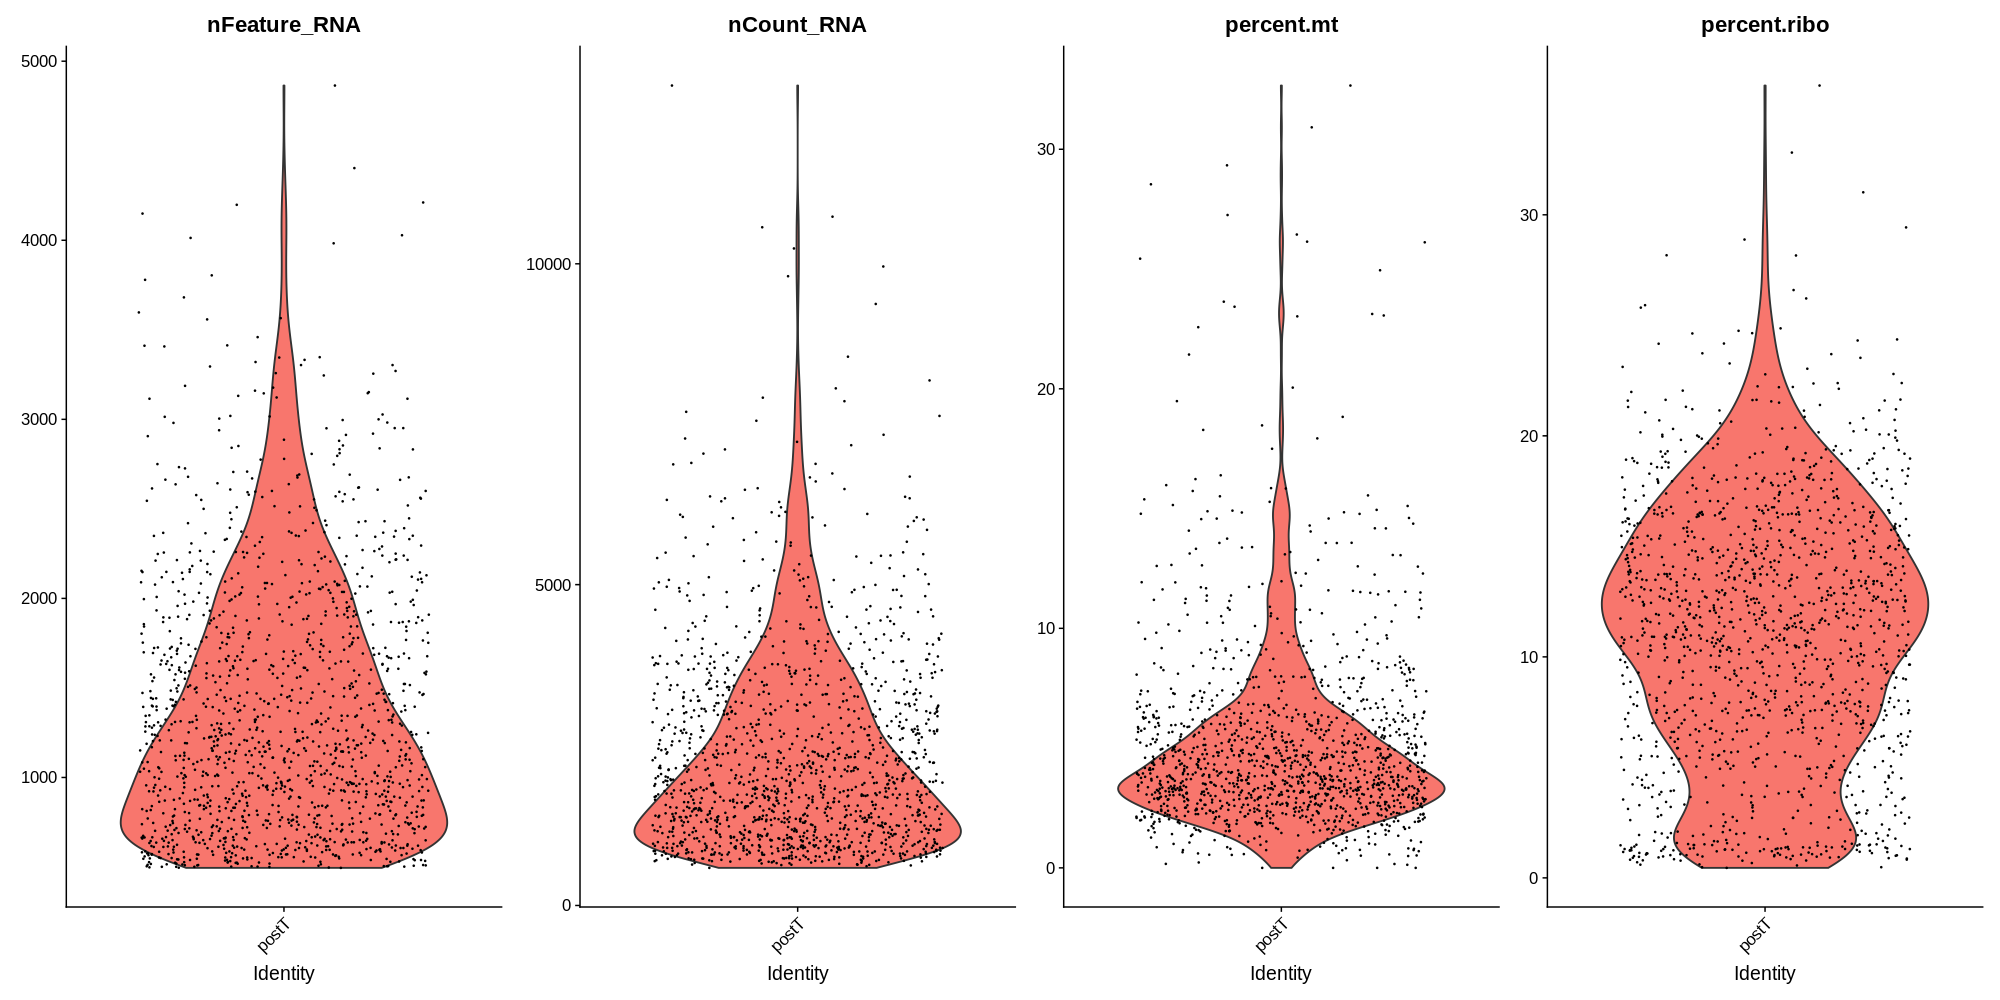

In [52]:
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 100)
VlnPlot(postT, features = c("nFeature_RNA", "nCount_RNA", "percent.mt", "percent.ribo"), ncol = 4)


### FeatureScatter is typically used to visualize feature-feature relationships, but can be used for anything calculated by the object, i.e. columns in object metadata, PC scores etc.

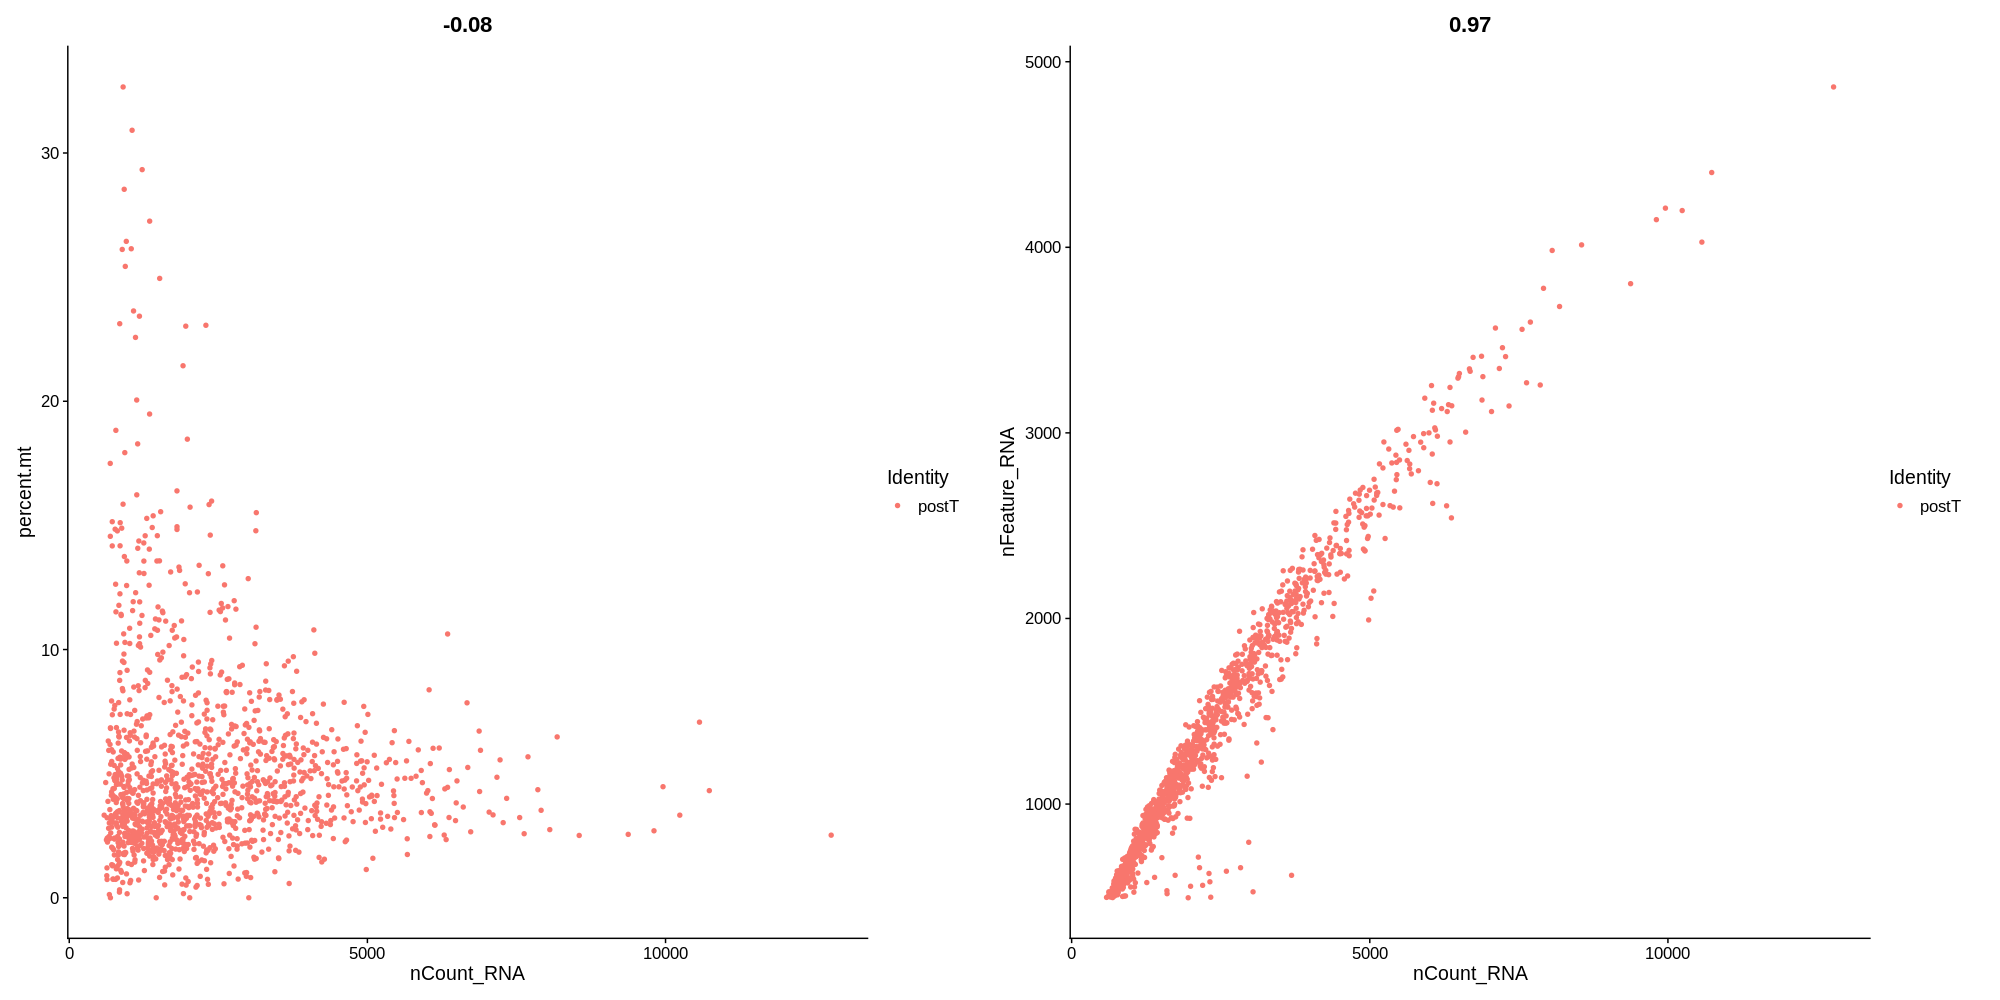

In [53]:
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 100)
plot1 <- FeatureScatter(postT, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(postT, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

### Outlier cells (Doublet) filtering filtering

In [54]:
postT <- subset(postT, subset = nFeature_RNA < 6800 & percent.mt < 10)
postT

An object of class Seurat 
20217 features across 1271 samples within 1 assay 
Active assay: RNA (20217 features, 0 variable features)
 1 layer present: counts

### FeatureScatter is typically used to visualize feature-feature relationships, but can be used for anything calculated by the object, i.e. columns in object metadata, PC scores etc.

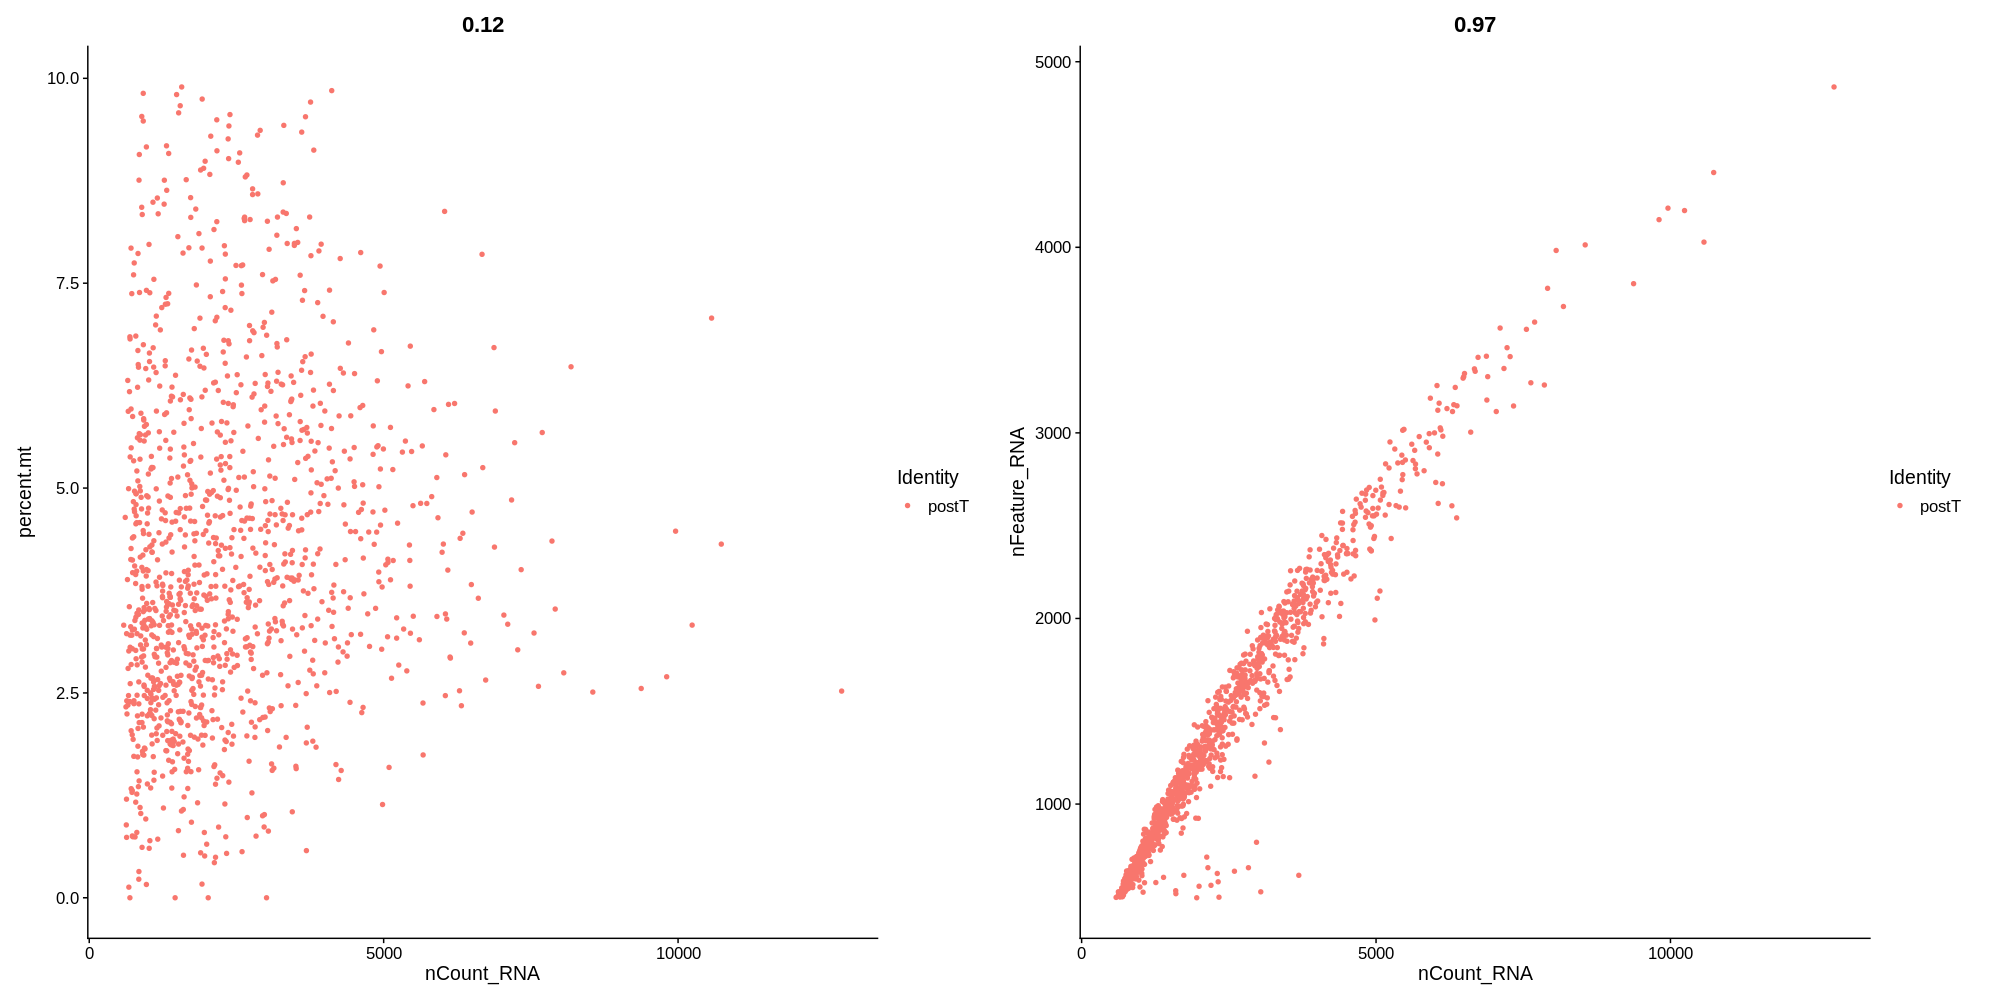

In [55]:
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 100)
plot1 <- FeatureScatter(postT, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(postT, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

In [56]:
# store mitochondrial percentage in object meta data
postT <- PercentageFeatureSet(postT, pattern = "^MT-", col.name = "percent.mt")
postT <- PercentageFeatureSet(postT, pattern = "^RB|^RP", col.name = "percent.ribo")


### Note that this single command replaces NormalizeData(), ScaleData(), and FindVariableFeatures().
### Transformed data will be available in the SCT assay, which is set as the default after running sctransform
### During normalization, we can also remove confounding sources of variation, for example, mitochondrial mapping percentage


In [57]:
# run sctransform
postT <- SCTransform(postT, vars.to.regress = "percent.mt", verbose = FALSE)

In [58]:
postT@meta.data$sample <- "postT"
postT

An object of class Seurat 
38128 features across 1271 samples within 2 assays 
Active assay: SCT (17911 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA

# End of post-treatment data processing

# **Pre integration step for integrating 5 datasets**

In [59]:
obj_combined_features <- SelectIntegrationFeatures(object.list = list(preT, postT), nfeatures = 3000)
obj_combined_anchor.list <- PrepSCTIntegration(object.list = list(preT, postT), anchor.features = obj_combined_features)

# Integrating all the 4 libraries

In [60]:
obj_combined.anchors <- FindIntegrationAnchors(object.list = obj_combined_anchor.list, normalization.method = "SCT", anchor.features = obj_combined_features)

Finding all pairwise anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 2291 anchors

Filtering anchors

	Retained 1822 anchors



In [61]:
obj_combined.integrated <- IntegrateData(anchorset = obj_combined.anchors, normalization.method = "SCT")

[1] 1


Warning message:
“Different cells and/or features from existing assay SCT”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”


[1] 2


Warning message:
“Different cells and/or features from existing assay SCT”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Merging dataset 1 into 2

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Assay integrated changing from Assay to SCTAssay”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Different cells and/or features from existing assay SCT”


In [62]:
obj_combined.integrated

An object of class Seurat 
44779 features across 1868 samples within 3 assays 
Active assay: integrated (3000 features, 3000 variable features)
 2 layers present: data, scale.data
 2 other assays present: RNA, SCT

# Run PCA

In [63]:
obj_combined.integrated <- RunPCA(object = obj_combined.integrated, verbose = FALSE)

## Including PCA Plot

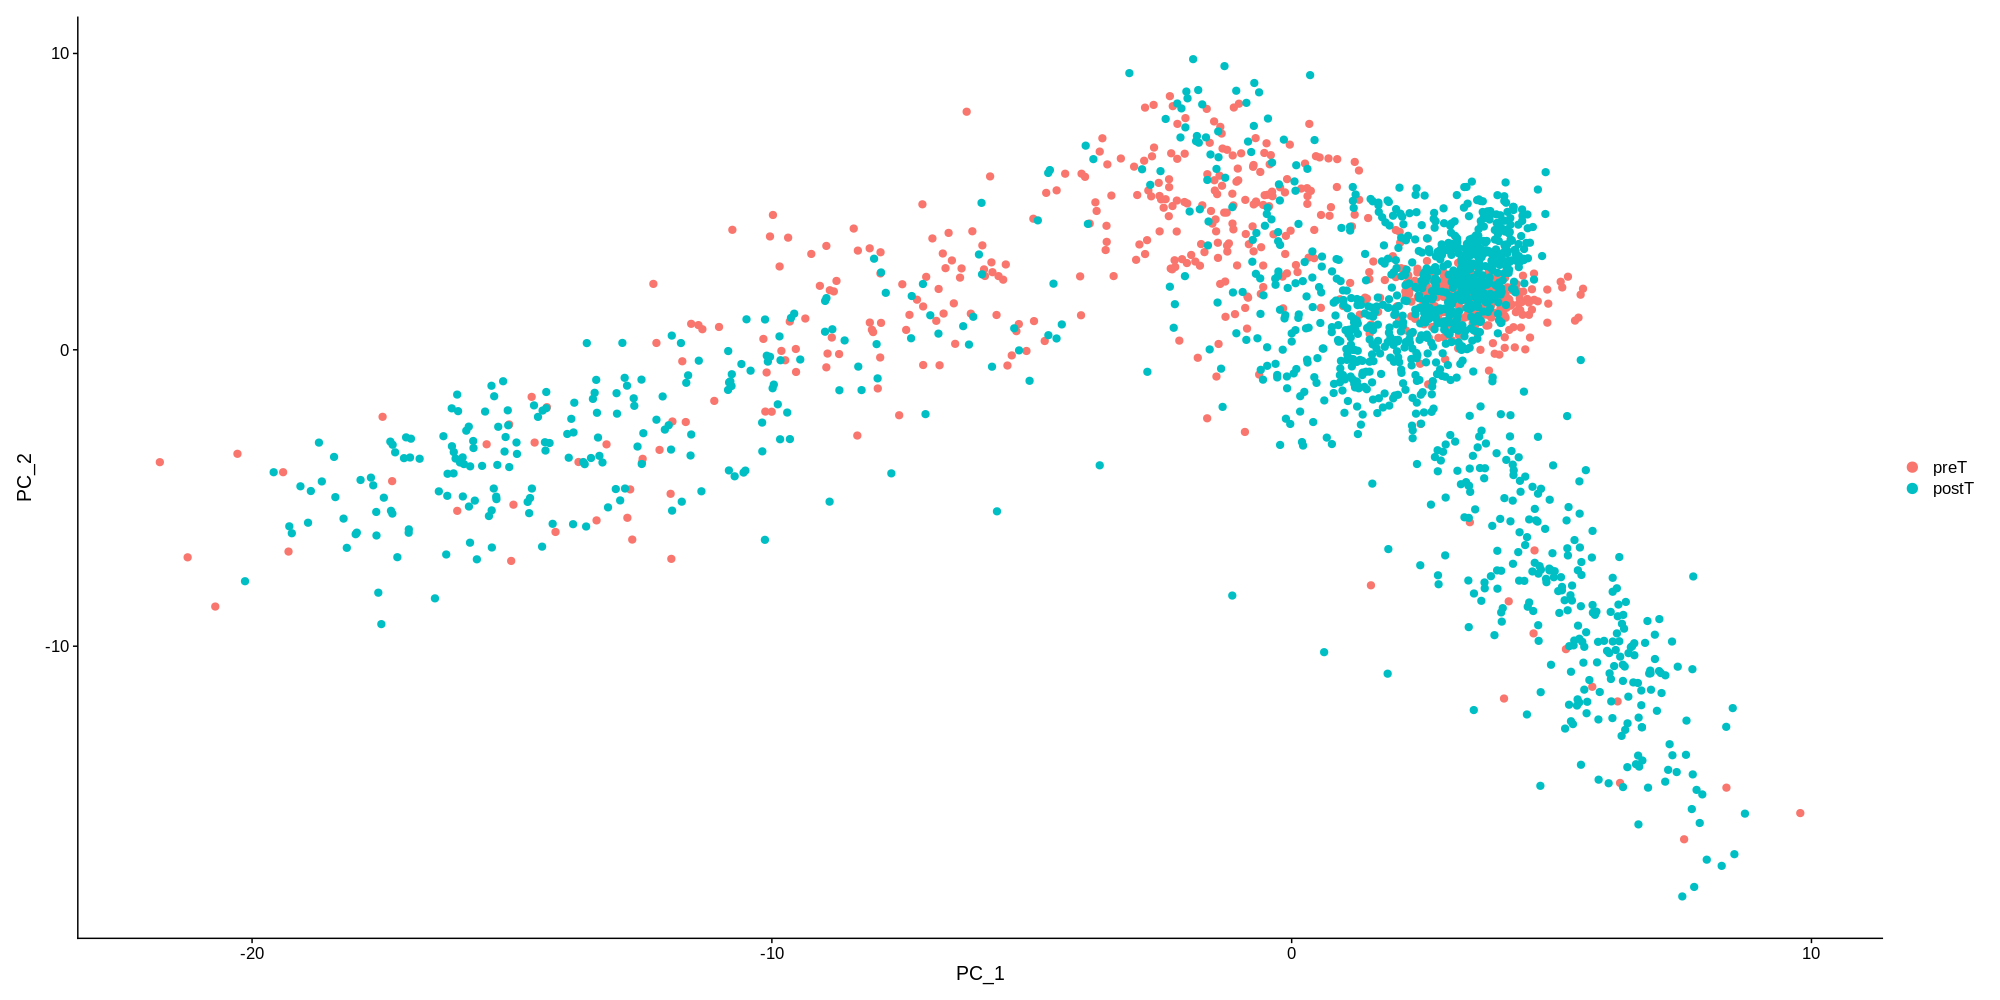

In [64]:
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 100)
DimPlot(obj_combined.integrated, reduction = "pca", pt.size = 2)

## Seurat provides several useful ways of visualizing both cells and features that define the PCA, including VizDimReduction, DimPlot, and DimHeatmap

In [65]:
# Examine and visualize PCA results a few different ways
print(obj_combined.integrated[["pca"]], dims = 1:5, nfeatures = 5)

PC_ 1 
Positive:  COL3A1, COL1A2, COL1A1, RPS18, IGFBP7 
Negative:  FTL, HLA-DRA, CD74, HLA-DRB1, C1QB 
PC_ 2 
Positive:  LINC-PINT, FYN, PTPRC, PTMA, RPS18 
Negative:  COL3A1, COL1A1, COL1A2, DCN, FN1 
PC_ 3 
Positive:  LINC-PINT, PTPRC, FYN, B2M, ARHGAP15 
Negative:  RPS18, FTL, FTH1, PTMA, KRT17 
PC_ 4 
Positive:  NEAT1, MALAT1, FNDC3B, ZSWIM6, SLC16A10 
Negative:  TMSB4X, B2M, RPS18, RPS12, RPLP1 
PC_ 5 
Positive:  SPP1, CCL4, IFI27, APOE, CCL5 
Negative:  NR3C1, NR4A3, GPR183, ZNF331, LINC-PINT 


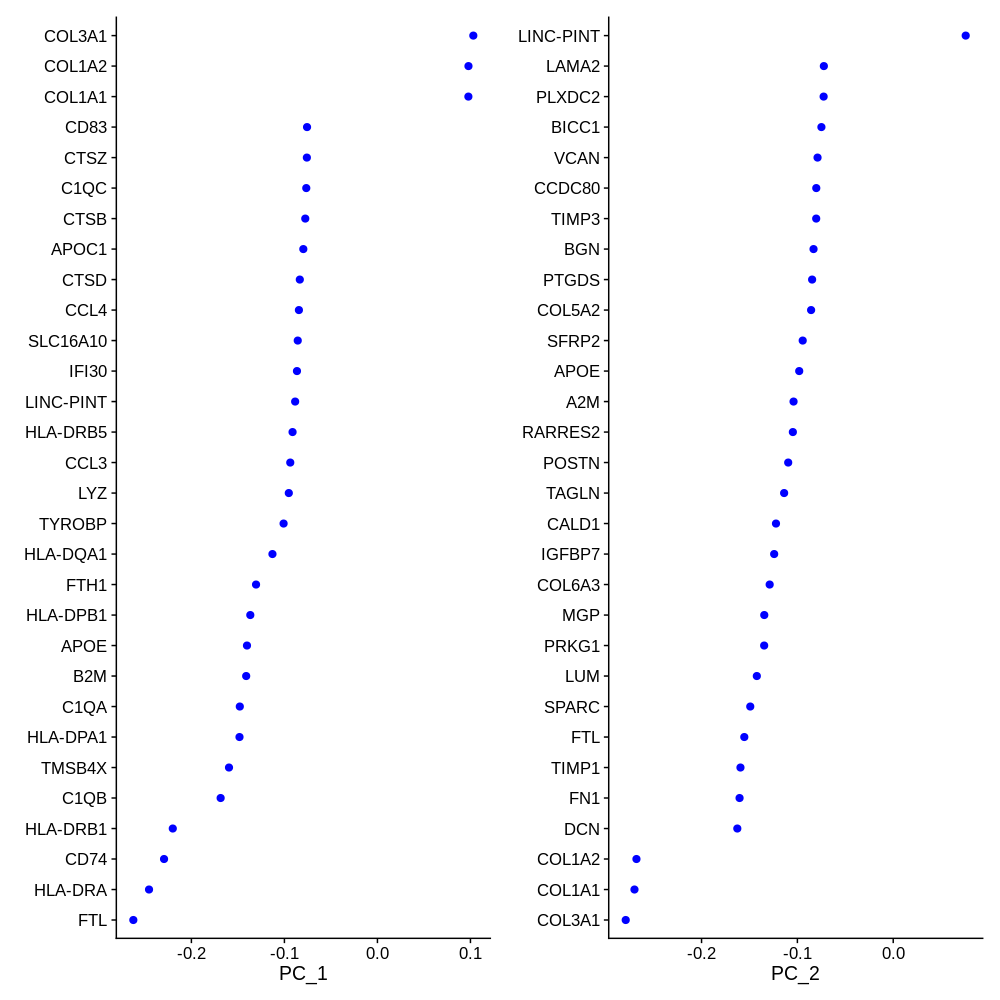

In [66]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)
VizDimLoadings(obj_combined.integrated, dims = 1:2, reduction = "pca")

## Finding Neighbors and Clusters with Resolution 0.4

In [67]:
obj_combined.integrated <- FindNeighbors(obj_combined.integrated, reduction = "pca", dims = 1:50)
obj_combined.integrated_res <- FindClusters(obj_combined.integrated, resolution = 0.4)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1868
Number of edges: 116416

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8331
Number of communities: 8
Elapsed time: 0 seconds


In [68]:
# Look at cluster IDs of the first 5 cells
head(Idents(obj_combined.integrated_res), 5)

AAACCCAAGTACAACA-1 AAACCCACATCCGGCA-1 AAACGAACAGGTGTGA-1 AAACGAAGTTCGTTCC-1 
                 0                  6                  3                  3 
AAAGAACTCCCATGGG-1 
                 0 
Levels: 0 1 2 3 4 5 6 7

## Run non-linear dimensional reduction (UMAP/tSNE)

Seurat offers several non-linear dimensional reduction techniques, such as tSNE and UMAP, to visualize and explore these datasets. The goal of these algorithms is to learn the underlying manifold of the data in order to place similar cells together in low-dimensional space. Cells within the graph-based clusters determined above should co-localize on these dimension reduction plots. As input to the UMAP and tSNE, we suggest using the same PCs as input to the clustering analysis.

In [69]:
obj_combined.integrated_res <- RunUMAP(obj_combined.integrated_res, dims = 1:50, verbose = FALSE)

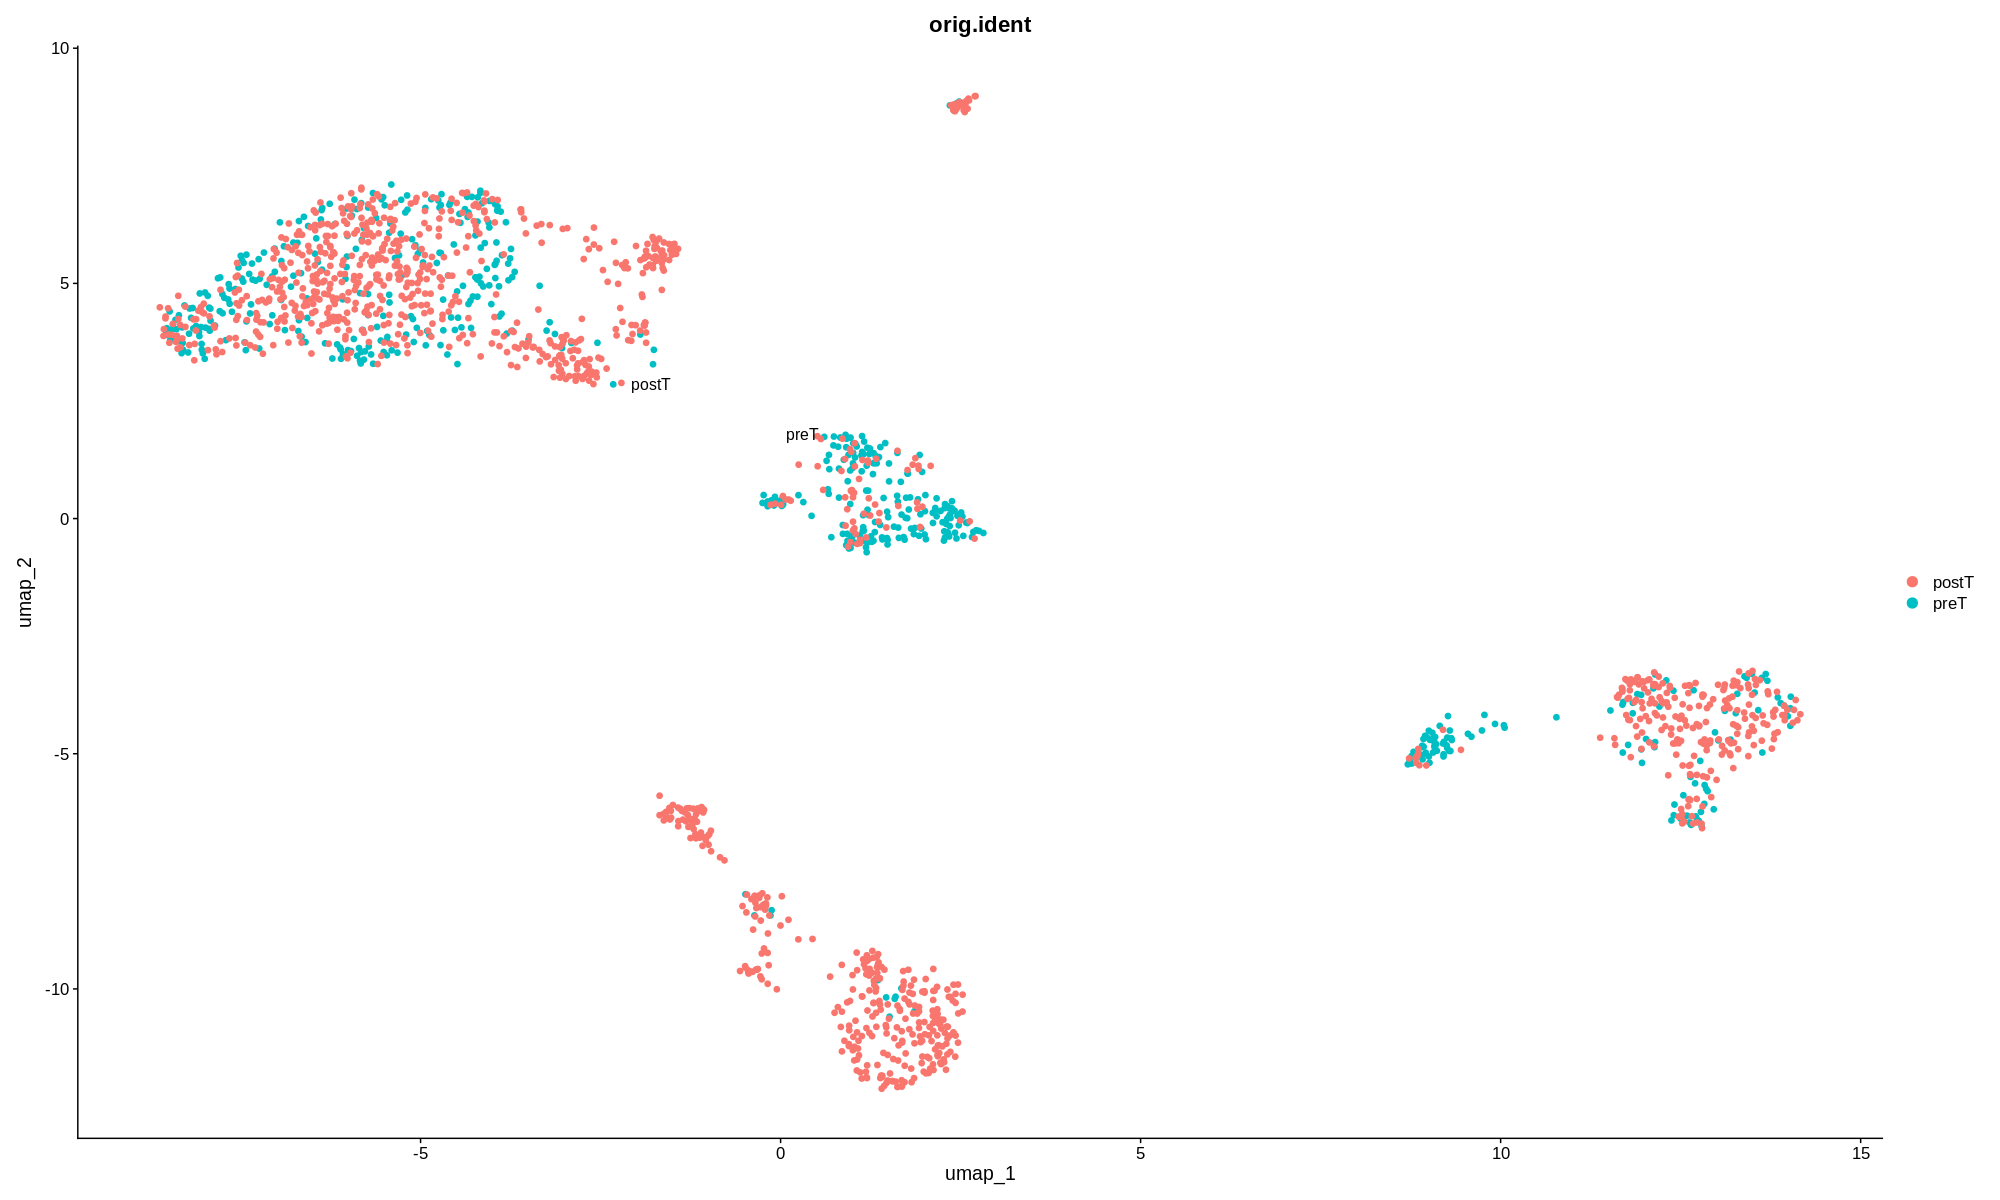

In [70]:
options(repr.plot.width = 20, repr.plot.height = 12, repr.plot.res = 100)
DimPlot(obj_combined.integrated_res, reduction = "umap", label = TRUE, group.by = "orig.ident", pt.size = 1.5, repel = T)

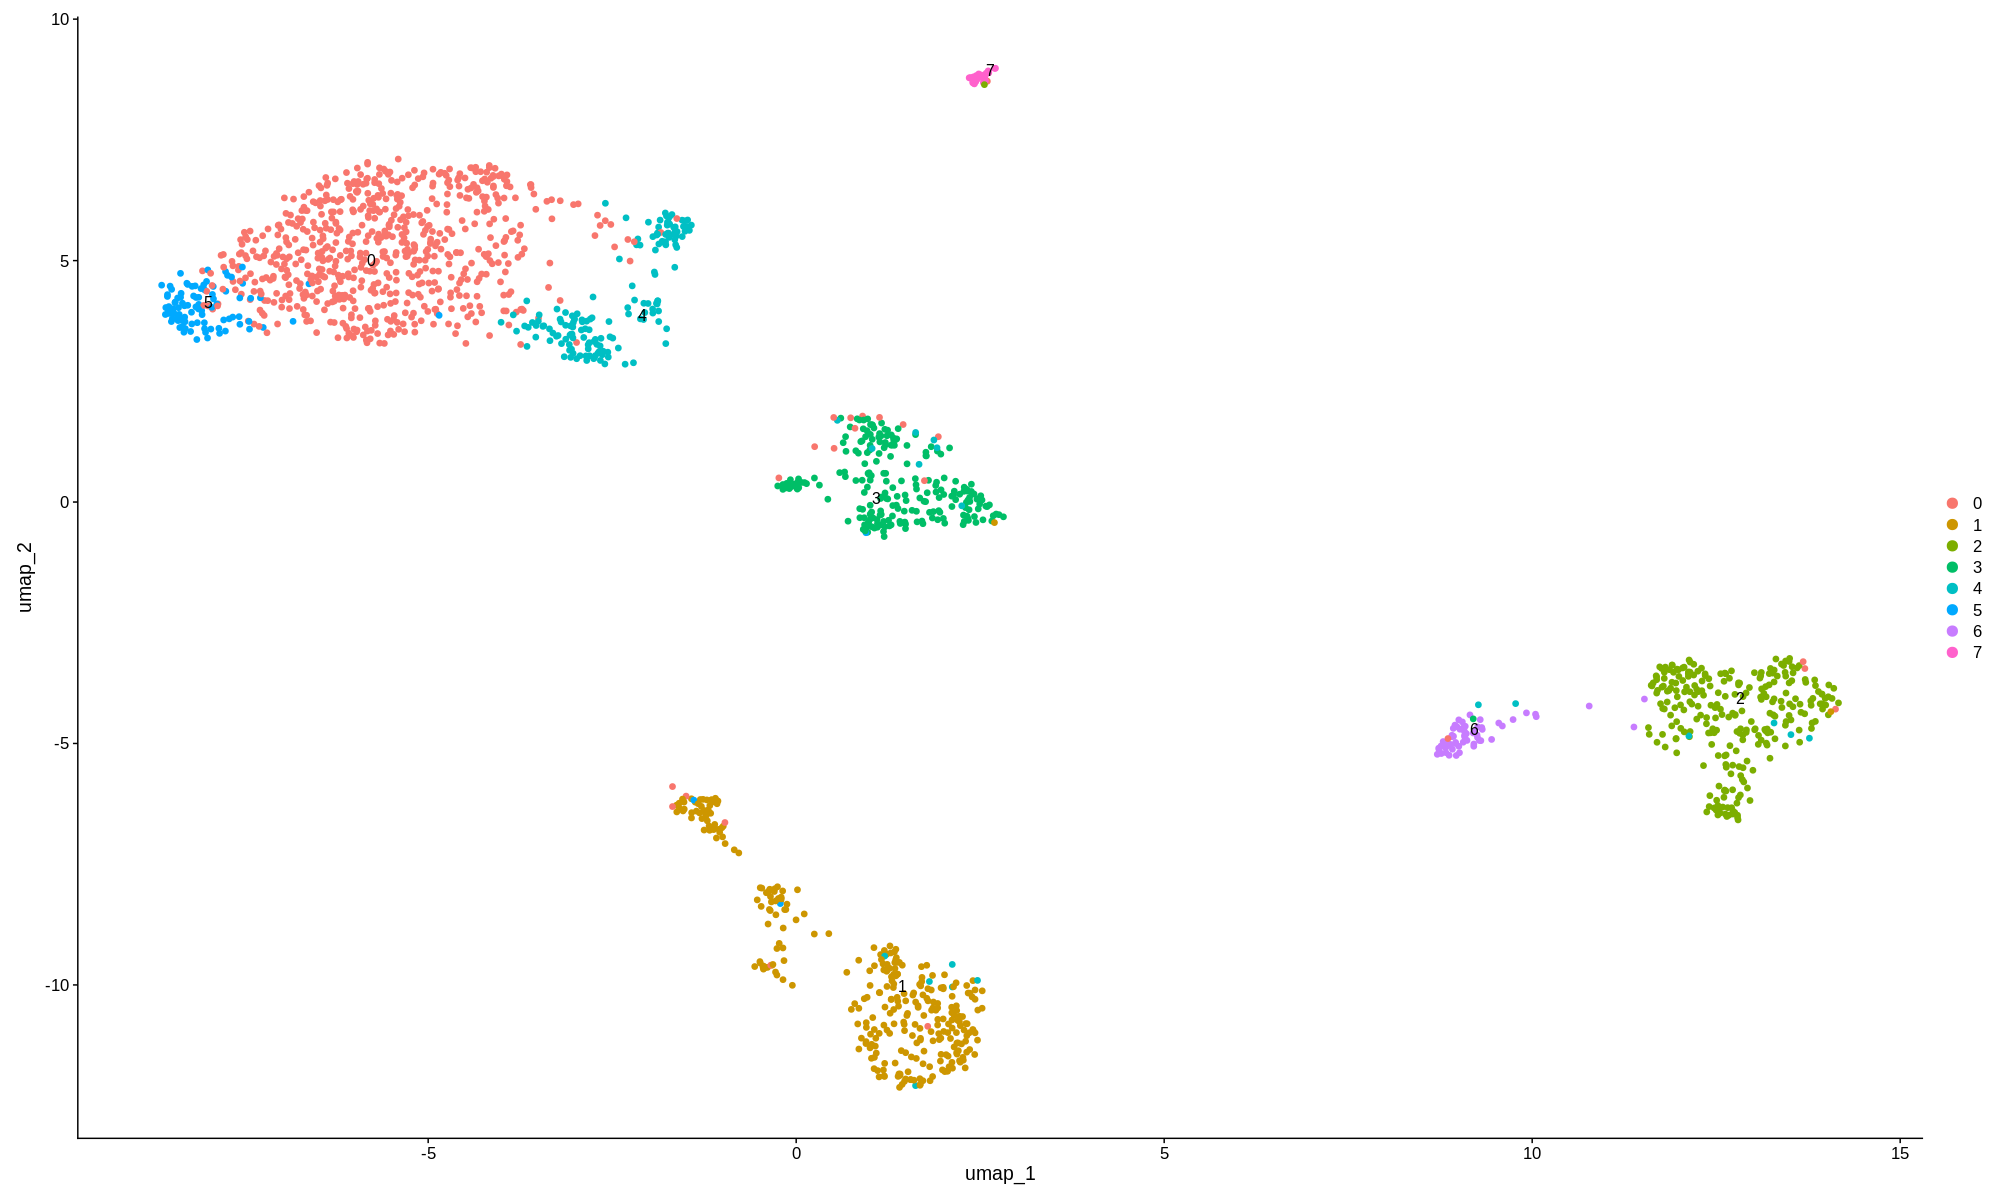

In [71]:
options(repr.plot.width = 20, repr.plot.height = 12, repr.plot.res = 100)
DimPlot(obj_combined.integrated_res, reduction = "umap", label = TRUE, pt.size = 1.5, repel = T)

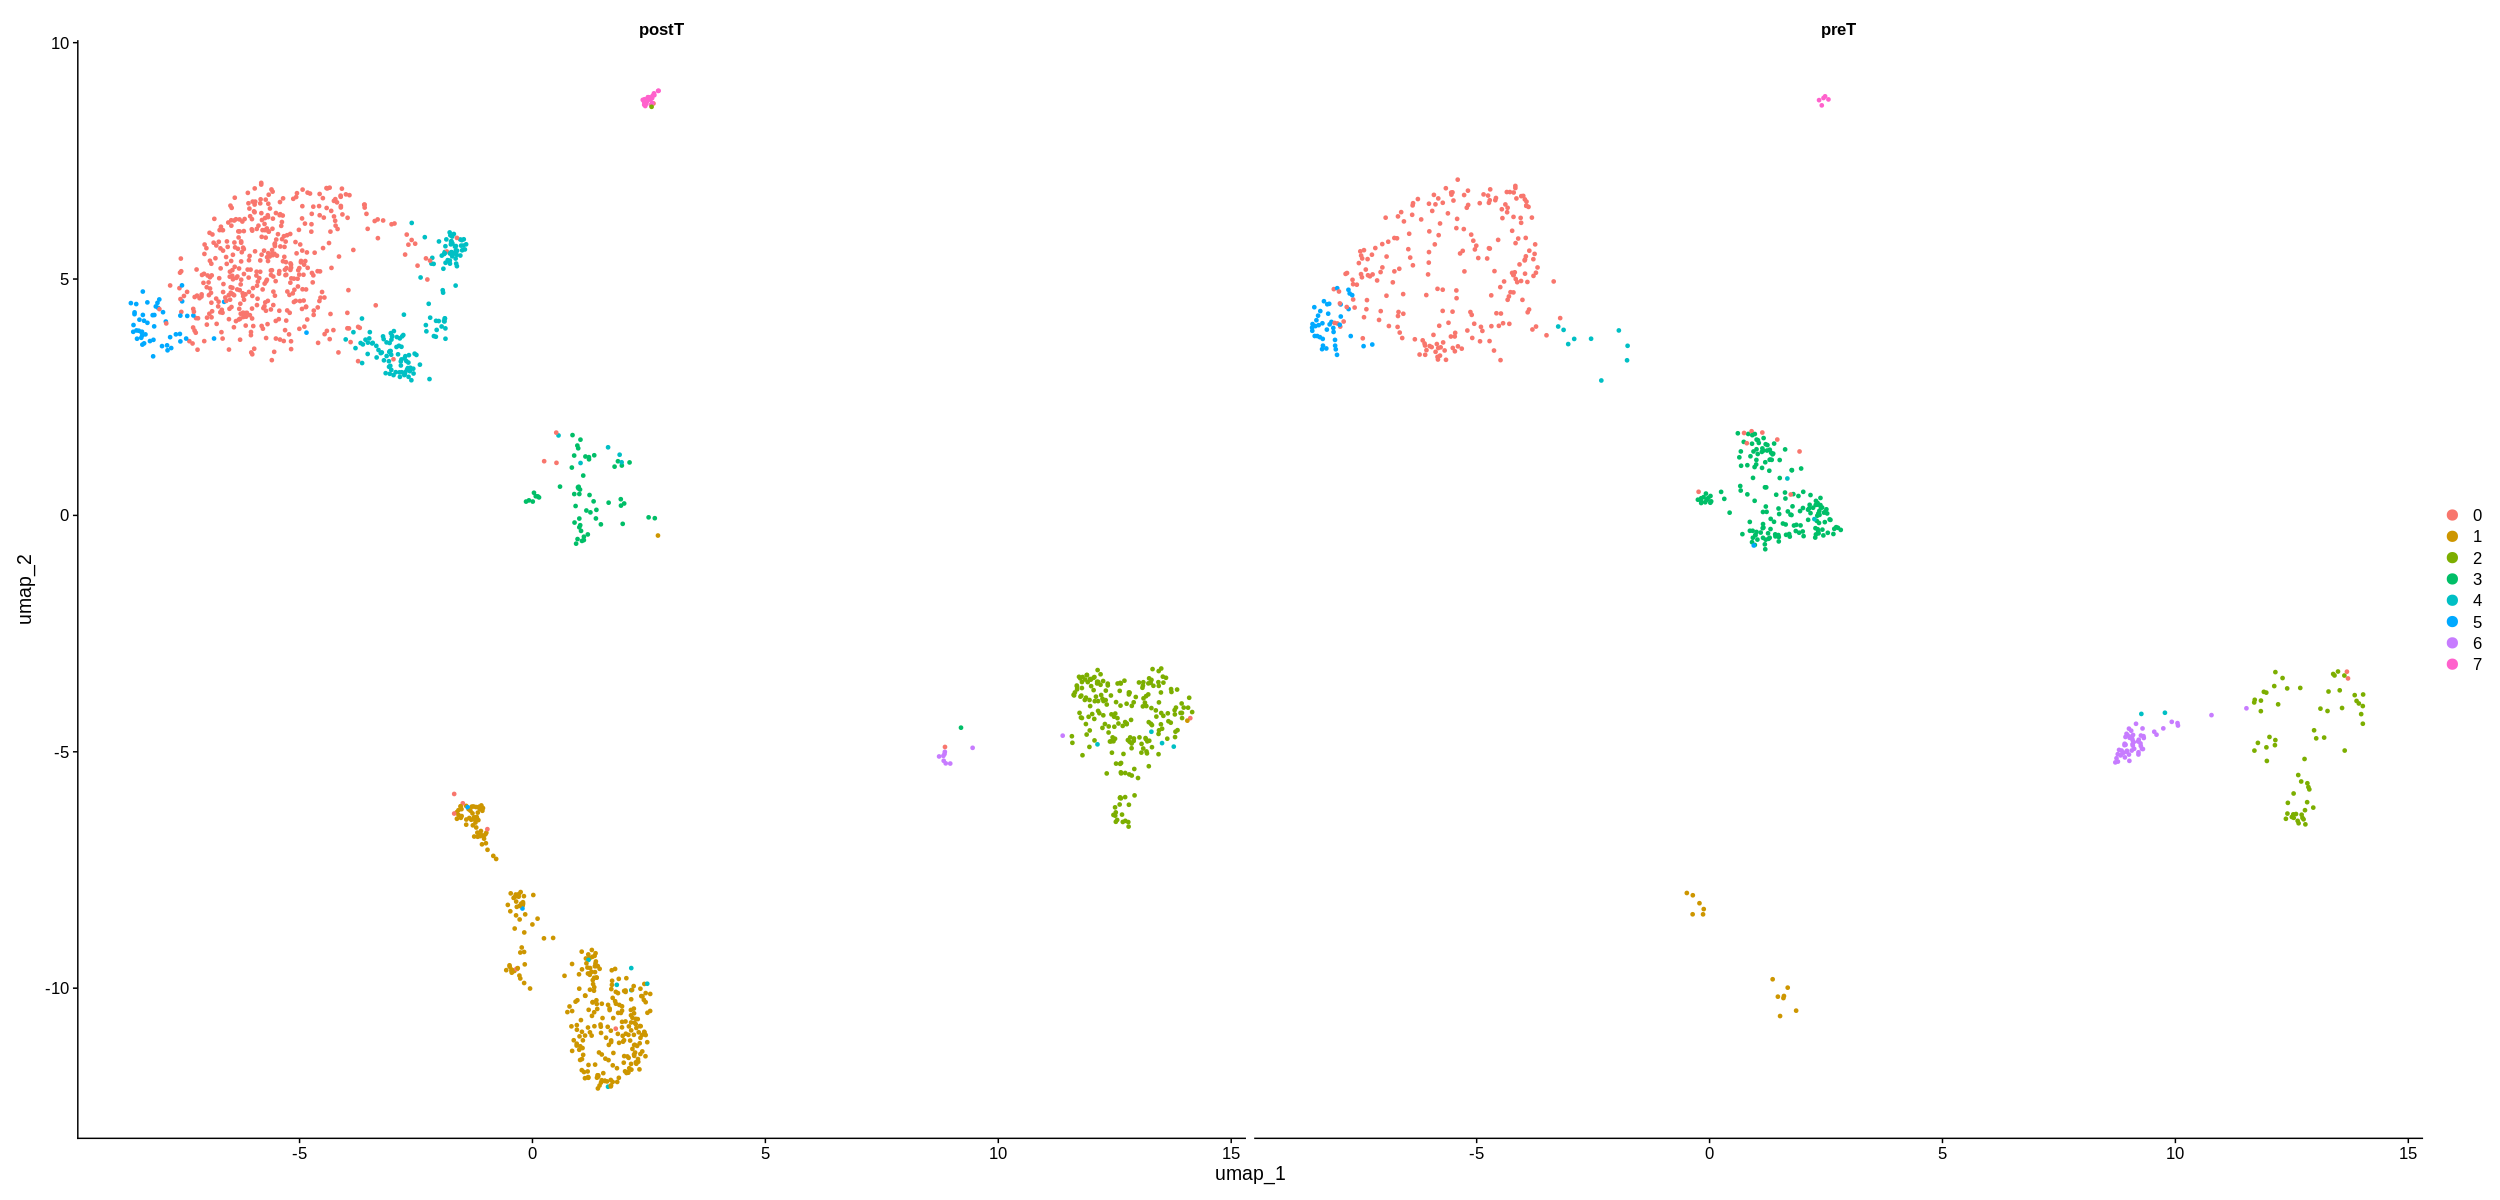

In [72]:
options(repr.plot.width = 25, repr.plot.height = 12, repr.plot.res = 100)
DimPlot(obj_combined.integrated_res, reduction = "umap", split.by = "orig.ident", ncol = 4, pt.size = 0.8)

In [73]:
head(obj_combined.integrated_res@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,nCount_SCT,nFeature_SCT,sample,integrated_snn_res.0.4,seurat_clusters
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>,<fct>
AAACCCAAGTACAACA-1,preT,21368.5062,5563,5.282856,15.69568,3466,1633,preT,0,0
AAACCCACATCCGGCA-1,preT,2185.0301,1247,4.433205,15.48117,4023,1233,preT,6,6
AAACGAACAGGTGTGA-1,preT,908.4158,597,5.403836,22.28934,3441,660,preT,3,3
AAACGAAGTTCGTTCC-1,preT,1209.6016,803,1.743179,16.28765,3658,830,preT,3,3
AAAGAACTCCCATGGG-1,preT,11959.1598,4019,5.681366,16.28661,3585,1671,preT,0,0
AAAGAACTCGGTGTAT-1,preT,1406.5290,790,3.526248,28.19537,3654,790,preT,3,3


## Silhouette plot

In [75]:
custom_colors <- list()

colors_dutch <- c(
  '#FFC312','#C4E538','#12CBC4','#FDA7DF','#ED4C67',
  '#F79F1F','#A3CB38','#1289A7','#D980FA','#B53471',
  '#EE5A24','#009432','#0652DD','#9980FA','#833471',
  '#EA2027','#006266','#1B1464','#5758BB','#6F1E51'
)

colors_spanish <- c(
  '#40407a','#706fd3','#f7f1e3','#34ace0','#33d9b2',
  '#2c2c54','#474787','#aaa69d','#227093','#218c74',
  '#ff5252','#ff793f','#d1ccc0','#ffb142','#ffda79',
  '#b33939','#cd6133','#84817a','#cc8e35','#ccae62'
)

custom_colors$discrete <- c(colors_dutch, colors_spanish)

custom_colors$cell_cycle <- setNames(
  c('#45aaf2', '#f1c40f', '#e74c3c', '#7f8c8d'),
  c('G1',      'S',       'G2M',     '-')
)




In [76]:
distance_matrix <- dist(Embeddings(obj_combined.integrated_res[['pca']])[, 1:5])
clusters <- obj_combined.integrated_res@meta.data$seurat_clusters
silhouette <- silhouette(as.numeric(clusters), dist = distance_matrix)
obj_combined.integrated_res@meta.data$silhouette_score <- silhouette[,3]

mean_silhouette_score <- mean(obj_combined.integrated_res@meta.data$silhouette_score)

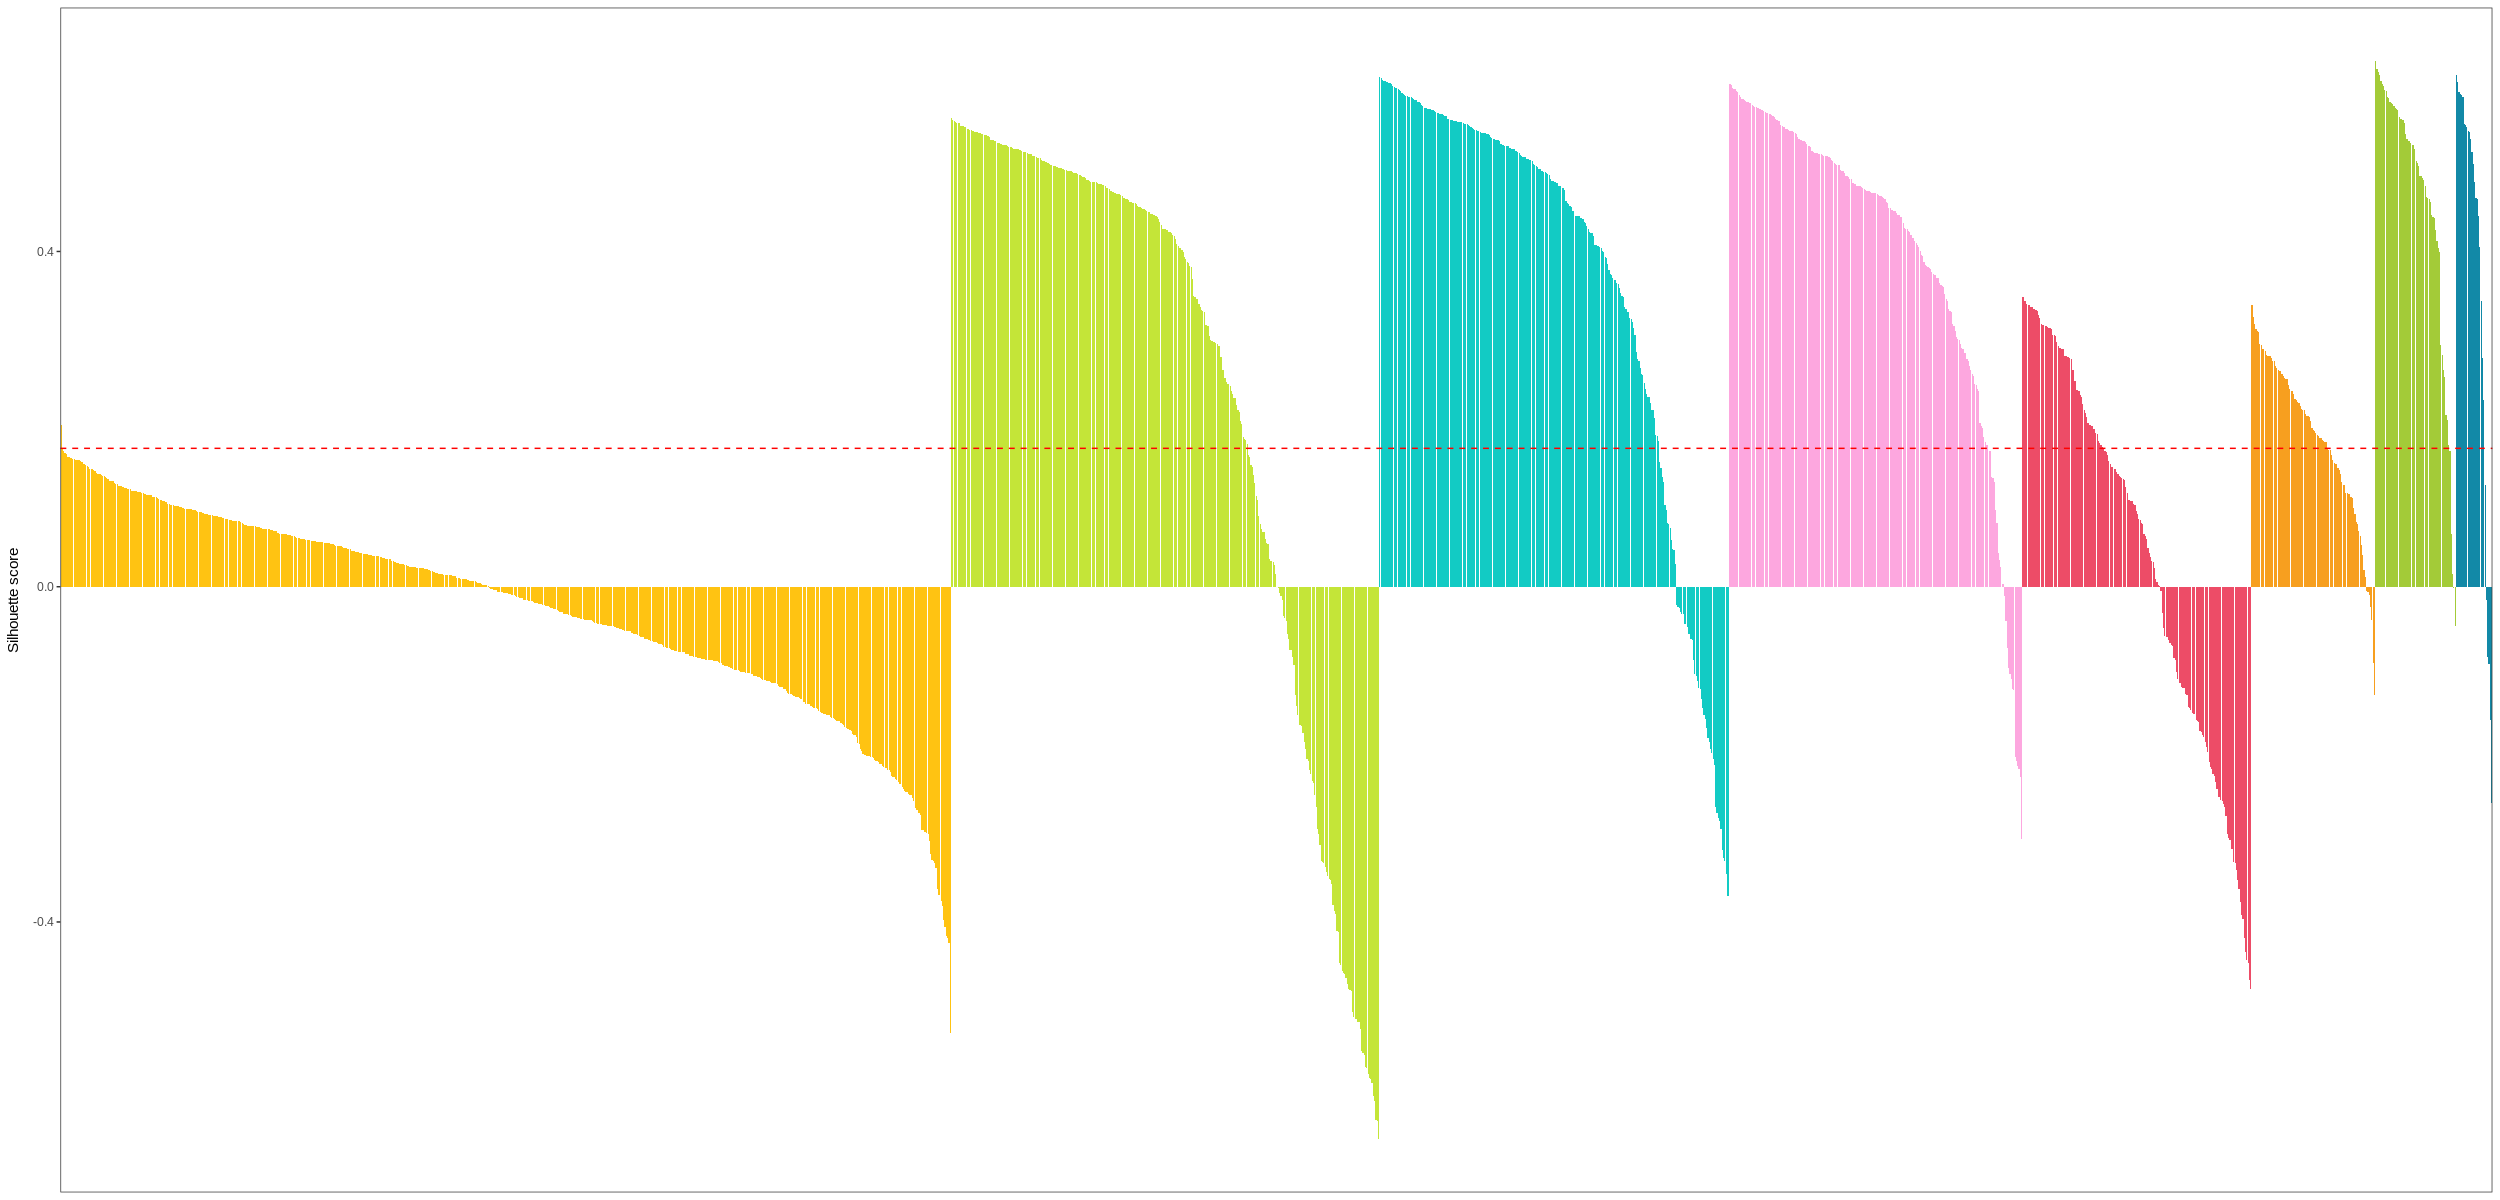

In [77]:
p <- obj_combined.integrated_res@meta.data %>%
  mutate(barcode = rownames(.)) %>%
  arrange(seurat_clusters,-silhouette_score) %>%
  mutate(barcode = factor(barcode, levels = barcode)) %>%
  ggplot() +
  geom_col(aes(barcode, silhouette_score, fill = seurat_clusters), show.legend = FALSE) +
  geom_hline(yintercept = mean_silhouette_score, color = 'red', linetype = 'dashed') +
  scale_x_discrete(name = 'Cells') +
  scale_y_continuous(name = 'Silhouette score') +
  scale_fill_manual(values = custom_colors$discrete) +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )
p



## Cluster similarity
Here, we use the clusterModularity() function from the scran package as described here. The heatmap below shows the difference between the observed and expected edge weights between each cluster pair.


Warning message:
“Layer ‘data’ is empty”
Warning message:
“Layer ‘scale.data’ is empty”
Warning message in .buildSNNGraph(reducedDim(x, use.dimred), d = NA, transposed = TRUE, :
“'buildSNNGraph' is deprecated.
Use 'bluster::makeSNNGraph' instead.
See help("Deprecated")”


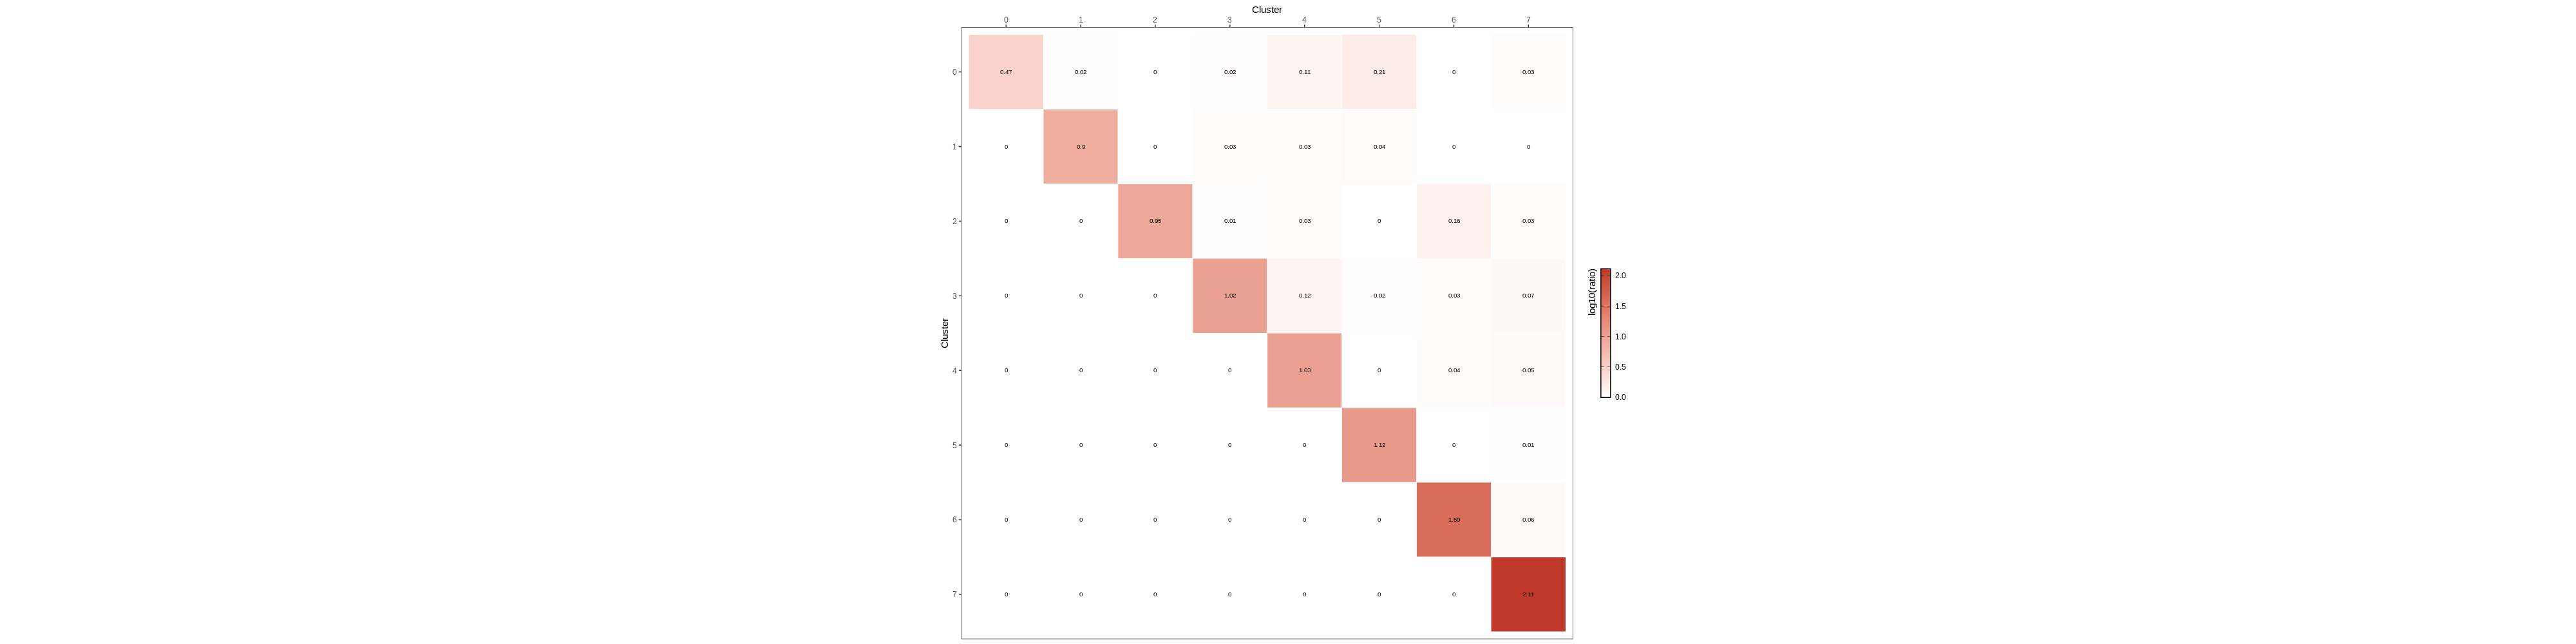

In [78]:
options(repr.plot.width = 40, repr.plot.height = 10, repr.plot.res = 100)
obj_combined.integrated_res <- JoinLayers(obj_combined.integrated_res, assay = "RNA")
sce <- as.SingleCellExperiment(obj_combined.integrated_res, assay = "RNA")


reducedDim(sce, 'PCA_sub') <- reducedDim(sce, 'PCA')[,1:15, drop = FALSE]

g <- scran::buildSNNGraph(sce, use.dimred = 'PCA_sub')

ratio <- bluster::pairwiseModularity(g, obj_combined.integrated_res@meta.data$seurat_clusters, as.ratio = TRUE)

ratio_to_plot <- log10(ratio+1)

p <- ratio_to_plot %>%
  as_tibble() %>%
  rownames_to_column(var = 'cluster_1') %>%
  pivot_longer(
    cols = 2:ncol(.),
    names_to = 'cluster_2',
    values_to = 'probability'
  ) %>%
  mutate(
    cluster_1 = as.character(as.numeric(cluster_1) - 1),
    cluster_1 = factor(cluster_1, levels = rev(unique(cluster_1))),
    cluster_2 = factor(cluster_2, levels = unique(cluster_2))
  ) %>%
  ggplot(aes(cluster_2, cluster_1, fill = probability)) +
  geom_tile(color = 'white') +
  geom_text(aes(label = round(probability, digits = 2)), size = 2.5) +
  scale_x_discrete(name = 'Cluster', position = 'top') +
  scale_y_discrete(name = 'Cluster') +
  scale_fill_gradient(
    name = 'log10(ratio)', low = 'white', high = '#c0392b', na.value = '#bdc3c7',
    guide = guide_colorbar(
      frame.colour = 'black', ticks.colour = 'black', title.position = 'left',
      title.theme = element_text(hjust = 1, angle = 90),
      barwidth = 0.75, barheight = 10
    )
  ) +
  coord_fixed() +
  theme_bw() +
  theme(
    legend.position = 'right',
    panel.grid.major = element_blank()
  )
p




## Cluster tree
The relationship (similarity) between clusters can be represented in a cluster tree. I find this useful to identify which clusters might be candidates for merging.

In [79]:
#install.packages('ape')
#library("BiocManager")
#BiocManager::install('ggtree')

In [81]:
seurat <- BuildClusterTree(
  obj_combined.integrated_res,
  dims = 1:15,
  reorder = FALSE,
  reorder.numeric = FALSE
)


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


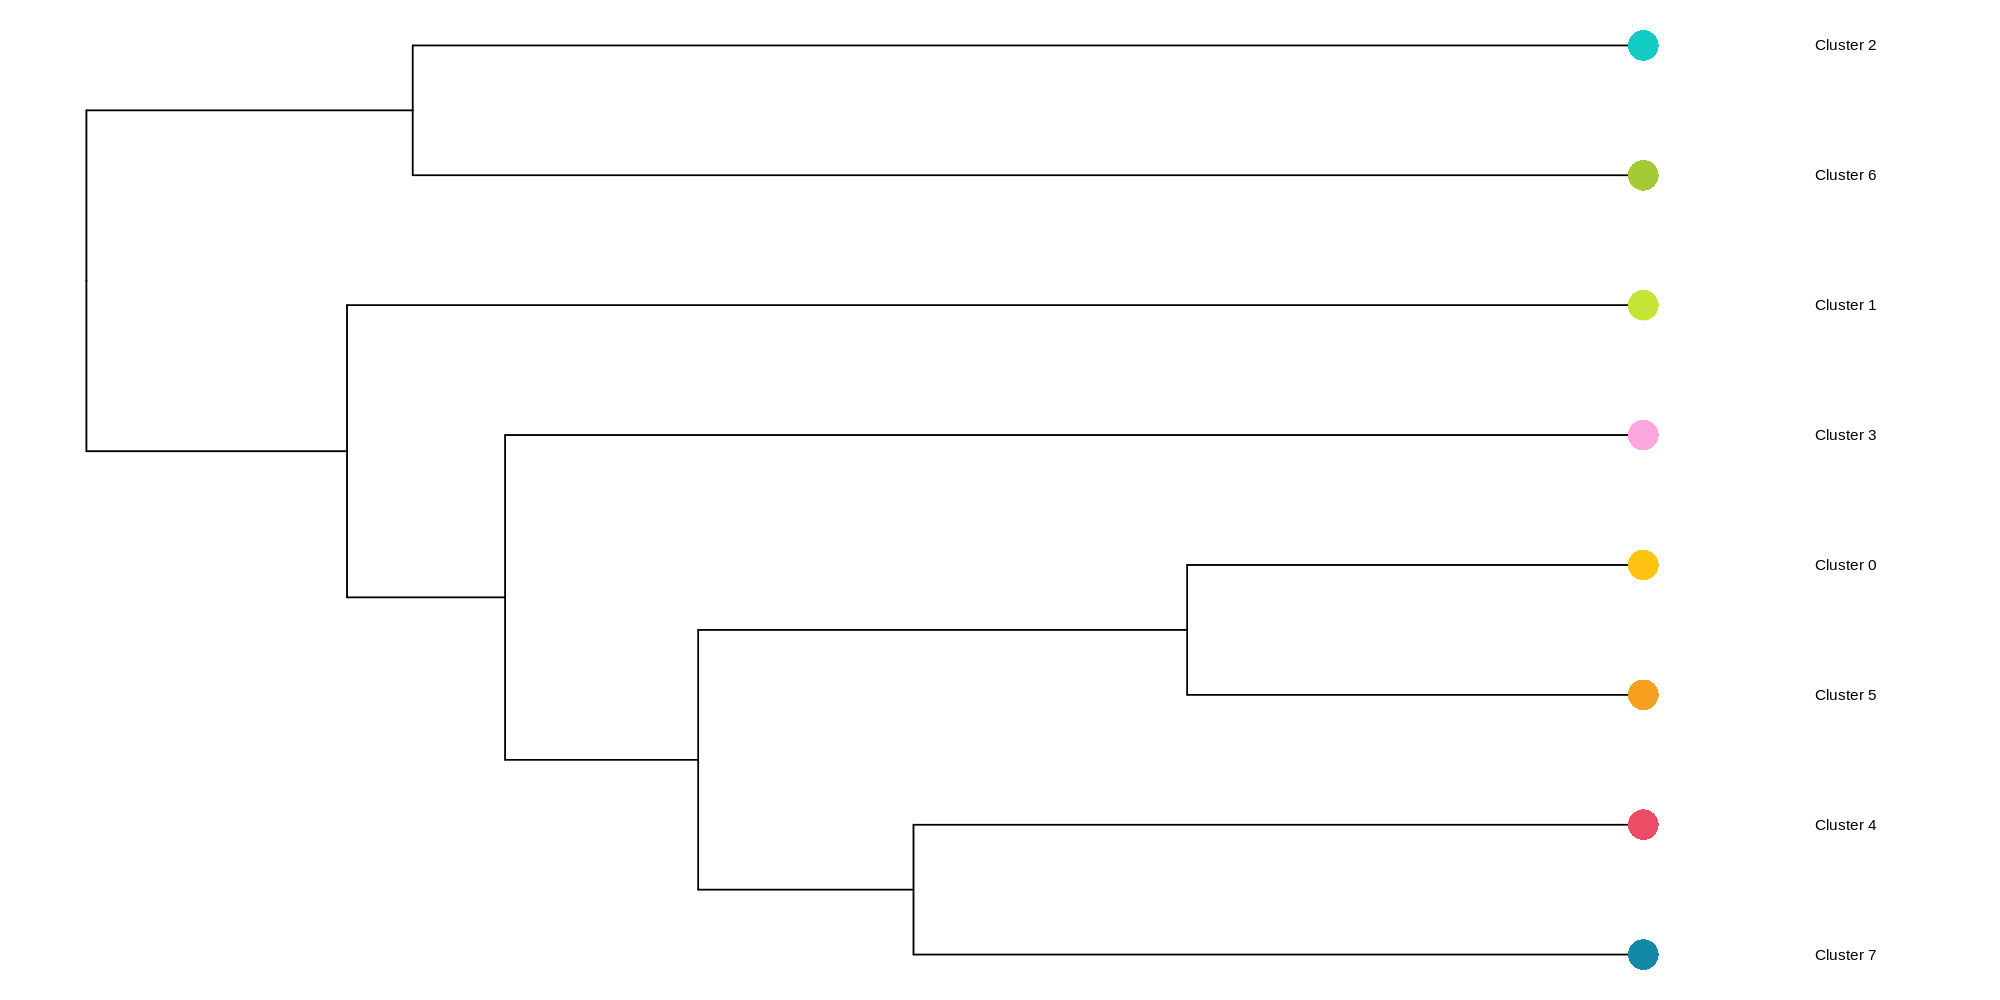

In [95]:
tree <- seurat@tools$BuildClusterTree
tree$tip.label <- paste0("Cluster ", tree$tip.label)

p <- ggtree::ggtree(tree, aes(x, y)) +
  scale_y_reverse() +
  ggtree::geom_tree() +
  ggtree::theme_tree() +
  ggtree::geom_tiplab(offset = 1) +
  ggtree::geom_tippoint(color = custom_colors$discrete[1:length(tree$tip.label)], shape = 16, size = 10) +
  coord_cartesian(clip = 'off') +
  theme(plot.margin = unit(c(0,2.5,0,0), 'cm'))
p

## Cell count by Sample

In [83]:
table(obj_combined.integrated_res$orig.ident)


postT  preT 
 1271   597 

## Cell count by cluster

In [84]:
table(obj_combined.integrated_res$seurat_clusters)


  0   1   2   3   4   5   6   7 
684 329 269 225 176  95  62  28 

In [85]:
table(obj_combined.integrated_res$seurat_clusters, obj_combined.integrated_res@meta.data$orig.ident)

   
    postT preT
  0   444  240
  1   316   13
  2   207   62
  3    56  169
  4   163   13
  5    53   42
  6     9   53
  7    23    5

## Count of cells per cluster

In [87]:
table_count <- table(obj_combined.integrated_res$seurat_clusters, obj_combined.integrated_res@meta.data$orig.ident)
table_count <- table_count %>% as.data.frame.matrix(table_count)

## Normalzied count of cells per cluster

In [88]:
apply(table_count, 2, function(x) {as.integer((x/sum(x))*10000)})

postT,preT
3493,4020
2486,217
1628,1038
440,2830
1282,217
416,703
70,887
180,83


## Plotting the normalized cell counts

In [89]:
table_count_rel <- as.data.frame(apply(table_count, 2, function(x) {as.integer((x/sum(x))*10000)}))
table_count_rel$clus <- rownames(table_count)
df <- melt(table_count_rel[,c("clus", 'preT', 'postT')], id.vars=1)

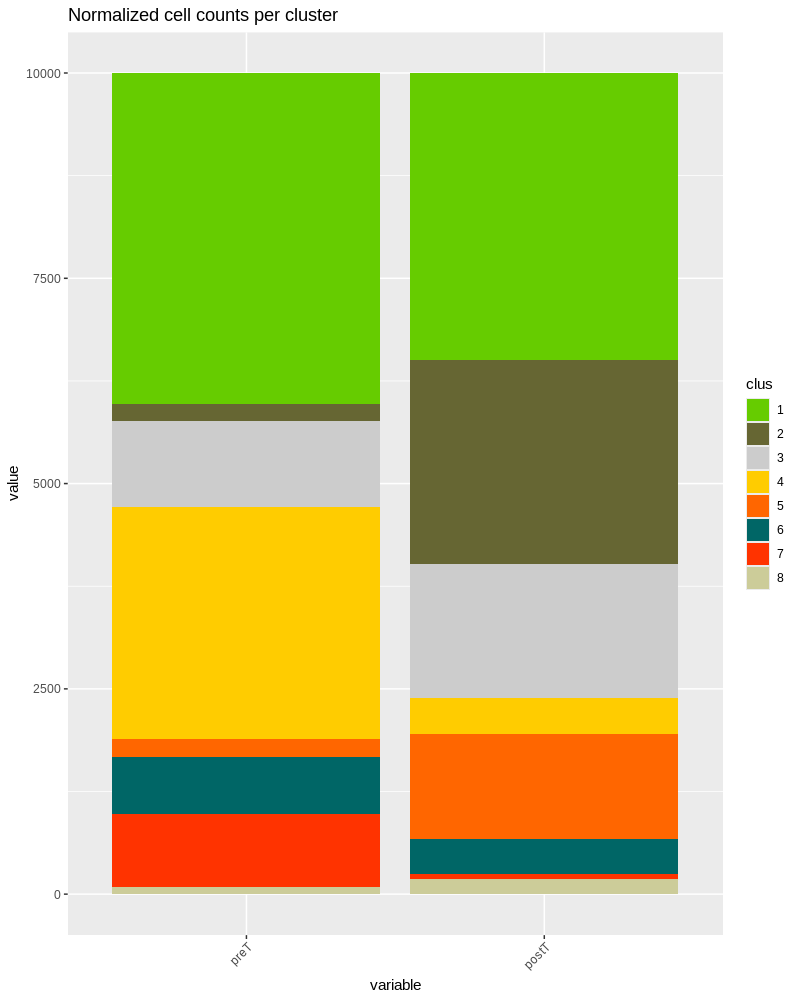

In [90]:
options(repr.plot.width = 8, repr.plot.height = 10, repr.plot.res = 100)
ggplot(df, aes(x = variable, y = value, fill = clus)) +
  geom_bar(position="stack", stat = "identity", width=0.9) +
  scale_fill_manual(values = c("#66CC00","#666633","#CCCCCC", "#FFCC00", "#FF6600", "#006666", "#FF3300", "#CCCC99", "#CC3300", "#0099CC", "#FF3399", "#990066", "#999999", "#006699", "#3399FF", "#99CCFF", "#FFFF00", "#330099", "#660066", "#FFCC66", "#FF9966", "#C5D8F3", "#7ECDBB", "#A6A6A6", "#E6916C", "#CDB7D2","#FBEFAB")) +
  ggtitle("Normalized cell counts per cluster") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Run TSNE

In [91]:
obj_combined.integrated_res <- RunTSNE(obj_combined.integrated_res, dims = 1:50)

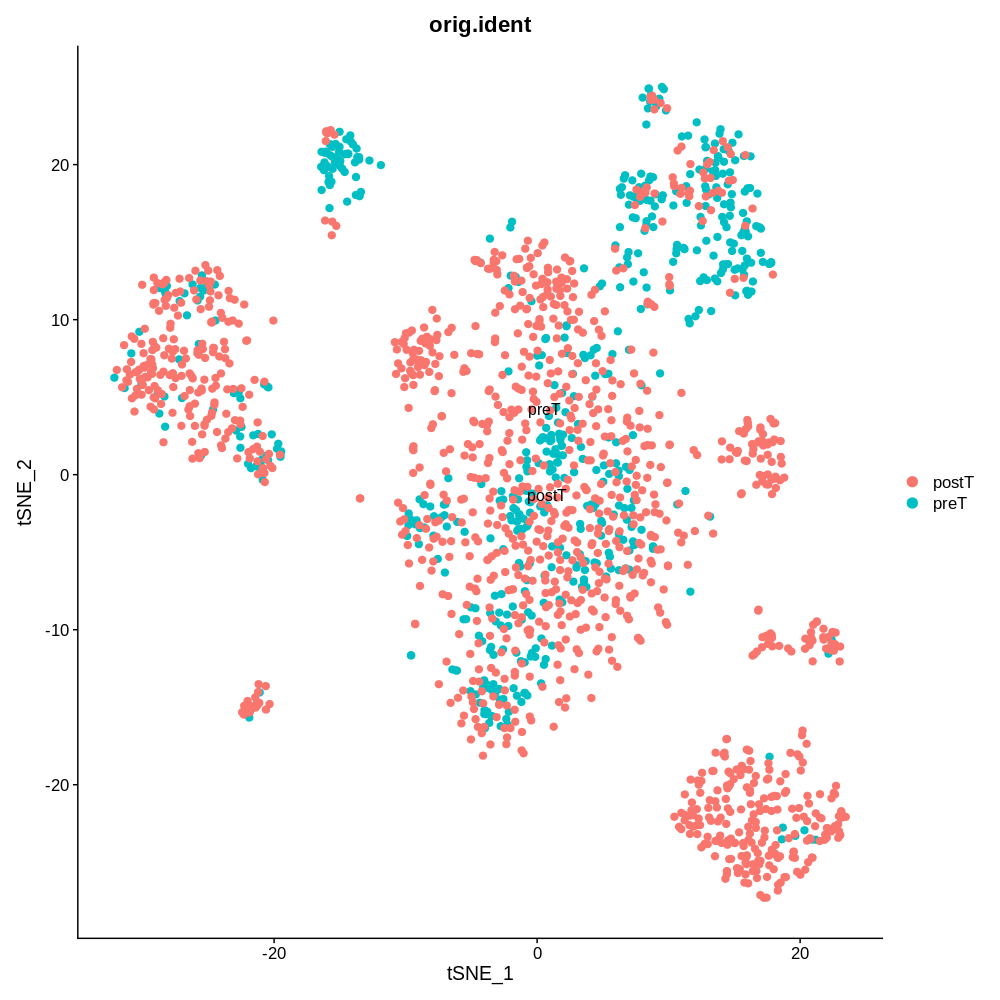

In [92]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)
DimPlot(obj_combined.integrated_res, reduction = "tsne", label = TRUE, group.by = "orig.ident", pt.size = 2, repel = TRUE)

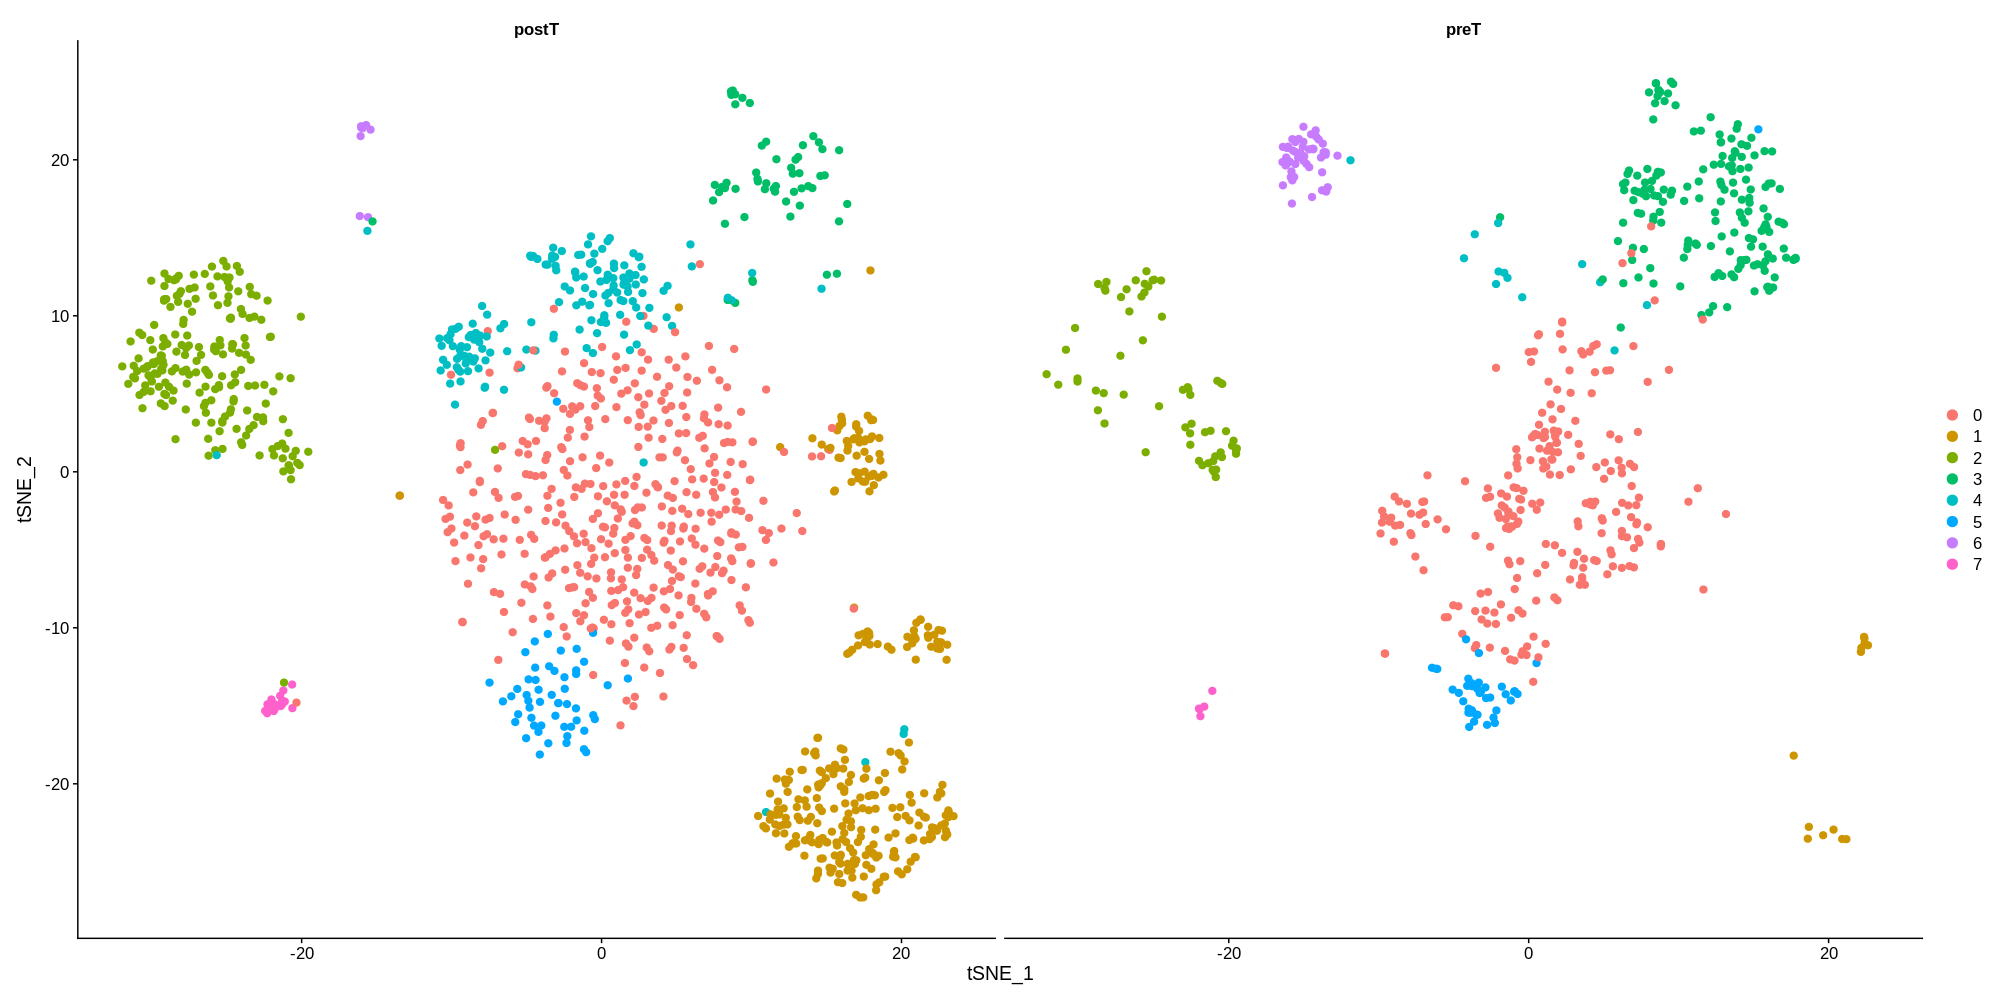

In [93]:
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 100)
DimPlot(obj_combined.integrated_res, reduction = "tsne", split.by = "orig.ident", ncol = 4, pt.size = 2)

# Saving the integrated Seurat object to be used later

In [94]:
saveRDS(obj_combined.integrated_res, file = "obj_combined.integrated_40res.rds")